## Splitting dataset into labeled (65k) and unlabeled (30k) sets.

In [ ]:
!pip install xgboost optuna scikit-learn pandas numpy

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/synthetic_insurance_claims_with_fraud_3%_label.csv').drop(columns=['fraud_probability_score'])
print(f"Total number of columns in df: {df.shape[1]}")
print(f"Total no of rows in df: {df.shape[0]}")
print(df.columns)

# Ensure 'fraud_label' is of integer type and handle potential NaNs
# sklearn's train_test_split with stratify does not accept NaN values.
if df['fraud_label'].isnull().any():
    nan_count = df['fraud_label'].isnull().sum()
    print(f"Warning: 'fraud_label' column contains {nan_count} NaN values. Filling with 0 to enable stratification.")
    df['fraud_label'] = df['fraud_label'].fillna(0).astype(int)
else:
    # If no NaNs, ensure it's still an integer type to prevent potential issues
    # with mixed types or float representation if read_csv inferred float.
    df['fraud_label'] = df['fraud_label'].astype(int)

print('% of fraud in data = ', df['fraud_label'].sum() / len(df) * 100)

df_labeled, df_unlabeled = train_test_split(df, test_size=30000, random_state=42, stratify=df['fraud_label'])

print('% of fraud in labeled_data = ', len(df_labeled), df_labeled['fraud_label'].sum() / len(df_labeled) * 100)
print('% of fraud in unlabeled_data = ', len(df_unlabeled), df_unlabeled['fraud_label'].sum() / len(df_unlabeled) * 100)

df_labeled.to_csv('labeled_synthetic_insurance_claims_with_fraud_3%_label.csv', index=False)
df_unlabeled.to_csv('unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv', index=False)

Total number of columns in df: 44
Total no of rows in df: 95000
Index(['claim_days_differenc', 'claim_loss_date_dom',
       'claim_loss_datet_to_policy_ply_icp_dt_delta',
       'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab',
       'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo',
       'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi',
       'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im',
       'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md',
       'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th',
       'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta',
       'sum_insured', 'reinstatement_value', 'credit_risk_score',
       'total_active_associate_cai', 'barriers_wide_score',
       'children_population', 'insurance_indicator', 'oc_code', 'policy_api',
       'policy_claim_free_year', 'policy_cld_cst1_aggregate',
       'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 

## Baseline models

### Case 1: Train (45k), val (10k) and test (10k) from labeled set only

In [ ]:
c1_train_data, c1_val_data = train_test_split(df_labeled, test_size=20000, random_state=42, stratify=df_labeled['fraud_label'])
c1_test_data, c1_val_data = train_test_split(c1_val_data, test_size=10000, random_state=42, stratify=c1_val_data['fraud_label'])

#### Accuracy based models

In [ ]:
import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, auc, log_loss)

def accuracy_based_baselines(train_data, val_data, test_data):
    # Define target column
    TARGET = 'fraud_label'

    # Split into features and labels
    X_train, y_train = train_data.drop(columns=[TARGET]), train_data[TARGET]
    X_val, y_val     = val_data.drop(columns=[TARGET]), val_data[TARGET]
    X_test, y_test   = test_data.drop(columns=[TARGET]), test_data[TARGET]

    # 1. Calculate Imbalance Weights
    # For XGBoost: ratio of negative to positive samples
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore", category=UserWarning) # Suppress convergence warnings during plotting

    # --- Logistic Regression Tuning ---
    def objective_lr(trial):
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])

        model = LogisticRegression(C=C, solver=solver, class_weight='balanced', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_lr = optuna.create_study(direction='maximize')
    study_lr.optimize(objective_lr, n_trials=10)
    print(f"Best LR Params: {study_lr.best_params}")

    # --- Decision Tree Tuning ---
    def objective_dt(trial):
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split,
                                       class_weight='balanced', random_state=42)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_dt = optuna.create_study(direction='maximize')
    study_dt.optimize(objective_dt, n_trials=10)
    print(f"Best DT Params: {study_dt.best_params}")

    # --- Random Forest Tuning ---
    def objective_rf(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                       min_samples_split=min_samples_split, class_weight='balanced',
                                       random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=10)
    print(f"Best RF Params: {study_rf.best_params}")

    # --- XGBoost Tuning ---
    def objective_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'eval_metric': 'logloss'
        }

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        probs = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, probs)

    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=10)
    print(f"Best XGB Params: {study_xgb.best_params}")

    # --- Train Final Models ---

    # 1. Logistic Regression
    best_lr = LogisticRegression(**study_lr.best_params, class_weight='balanced', max_iter=1000, random_state=42)
    best_lr.fit(X_train, y_train)
    lr_preds = best_lr.predict(X_test)
    lr_probs = best_lr.predict_proba(X_test)[:, 1]

    # Custom loop to extract simulated epoch loss for LR
    lr_train_loss, lr_val_loss = [], []
    lr_epochs = list(range(1, 101, 5))
    for epochs in lr_epochs:
        temp_lr = LogisticRegression(**study_lr.best_params, class_weight='balanced', max_iter=epochs, random_state=42)
        temp_lr.fit(X_train, y_train)
        lr_train_loss.append(log_loss(y_train, temp_lr.predict_proba(X_train)))
        lr_val_loss.append(log_loss(y_val, temp_lr.predict_proba(X_val)))

    # 2. Decision Tree (Single-shot algorithm, tracking static final loss for plotting)
    best_dt = DecisionTreeClassifier(**study_dt.best_params, class_weight='balanced', random_state=42)
    best_dt.fit(X_train, y_train)
    dt_preds = best_dt.predict(X_test)
    dt_probs = best_dt.predict_proba(X_test)[:, 1]

    dt_train_loss = log_loss(y_train, best_dt.predict_proba(X_train))
    dt_val_loss = log_loss(y_val, best_dt.predict_proba(X_val))

    # 3. Random Forest
    best_rf = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=42, n_jobs=-1)
    best_rf.fit(X_train, y_train)
    rf_preds = best_rf.predict(X_test)
    rf_probs = best_rf.predict_proba(X_test)[:, 1]

    # Custom loop to extract simulated estimator loss for RF
    rf_train_loss, rf_val_loss = [], []
    rf_epochs = list(range(1, study_rf.best_params['n_estimators'] + 1, max(1, study_rf.best_params['n_estimators'] // 20)))
    for estimators in rf_epochs:
        rf_params = study_rf.best_params.copy()
        rf_params['n_estimators'] = estimators
        temp_rf = RandomForestClassifier(**rf_params, class_weight='balanced', random_state=42, n_jobs=-1)
        temp_rf.fit(X_train, y_train)
        rf_train_loss.append(log_loss(y_train, temp_rf.predict_proba(X_train)))
        rf_val_loss.append(log_loss(y_val, temp_rf.predict_proba(X_val)))

    # 4. XGBoost
    best_xgb = xgb.XGBClassifier(**study_xgb.best_params, scale_pos_weight=scale_pos_weight,
                                random_state=42, eval_metric=['logloss'])
    best_xgb.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    xgb_preds = best_xgb.predict(X_test)
    xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

    # --- Compile Test Set Metrics ---
    def get_metrics(y_true, y_pred, y_prob, model_name):
        return {
            'Model': model_name,
            'ROC-AUC': roc_auc_score(y_true, y_prob),
            'F1-Score': f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred)
        }

    results_df = pd.DataFrame([
        get_metrics(y_test, lr_preds, lr_probs, "Logistic Regression"),
        get_metrics(y_test, dt_preds, dt_probs, "Decision Tree"),
        get_metrics(y_test, rf_preds, rf_probs, "Random Forest"),
        get_metrics(y_test, xgb_preds, xgb_probs, "XGBoost")
    ])

    print("\n--- Final Test Set Performance ---")
    try:
        display(results_df)
    except NameError:
        print(results_df.to_string())

    # --- Plotting ---
    fig = plt.figure(figsize=(18, 16)) # Slightly taller to accommodate 3 rows natively
    sns.set_theme(style="whitegrid")

    # 1. Combined Learning Curves (Top row)
    ax1 = plt.subplot(3, 1, 1)

    # XGBoost
    xgb_results = best_xgb.evals_result()
    xgb_epochs = range(0, len(xgb_results['validation_0']['logloss']))
    ax1.plot(xgb_epochs, xgb_results['validation_0']['logloss'], label='XGB Train Loss', color='blue', linestyle='-')
    ax1.plot(xgb_epochs, xgb_results['validation_1']['logloss'], label='XGB Val Loss', color='cyan', linestyle='--')

    # Logistic Regression
    ax1.plot(lr_epochs, lr_train_loss, label='LR Train Loss', color='red', linestyle='-')
    ax1.plot(lr_epochs, lr_val_loss, label='LR Val Loss', color='orange', linestyle='--')

    # Random Forest
    ax1.plot(rf_epochs, rf_train_loss, label='RF Train Loss', color='green', linestyle='-')
    ax1.plot(rf_epochs, rf_val_loss, label='RF Val Loss', color='lime', linestyle='--')

    # Decision Tree (Horizontal lines as it is non-iterative)
    ax1.axhline(dt_train_loss, label='DT Train Loss (Static)', color='purple', linestyle='-')
    ax1.axhline(dt_val_loss, label='DT Val Loss (Static)', color='magenta', linestyle='--')

    ax1.set_title('Combined Learning Curves: All Models (Log Loss)')
    ax1.set_xlabel('Iterations / Boosting Rounds / Estimators')
    ax1.set_ylabel('Log Loss')
    ax1.legend(loc='upper right')

    # Data lists for automated plotting loops
    models_data = [
        ("Logistic Regression", lr_probs, lr_preds),
        ("Decision Tree", dt_probs, dt_preds),
        ("Random Forest", rf_probs, rf_preds),
        ("XGBoost", xgb_probs, xgb_preds)
    ]

    # 2. Precision-Recall Curve (Middle Left)
    ax2 = plt.subplot(3, 2, 3)
    for model_name, probs, _ in models_data:
        precision, recall, _ = precision_recall_curve(y_test, probs)
        pr_auc = auc(recall, precision)
        ax2.plot(recall, precision, label=f'{model_name} (AUC={pr_auc:.3f})')

    ax2.set_title('Precision-Recall Curve (Test Set)')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend()

    # 3. ROC Curve (Middle Right)
    ax3 = plt.subplot(3, 2, 4)
    for model_name, probs, _ in models_data:
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_auc = roc_auc_score(y_test, probs)
        ax3.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})')

    ax3.plot([0, 1], [0, 1], 'k--')
    ax3.set_title('ROC-AUC Curve (Test Set)')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.legend()

    # 4. Confusion Matrices (Bottom Row - 4 across)
    axes_cm = [
        plt.subplot(3, 4, 9),
        plt.subplot(3, 4, 10),
        plt.subplot(3, 4, 11),
        plt.subplot(3, 4, 12)
    ]

    cm_cmaps = ['Oranges', 'Purples', 'Greens', 'Blues']

    for i, (model_name, _, preds) in enumerate(models_data):
        sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap=cm_cmaps[i], ax=axes_cm[i], cbar=False)
        axes_cm[i].set_title(f'CM: {model_name}')
        axes_cm[i].set_xlabel('Predicted')
        if i == 0:
            axes_cm[i].set_ylabel('True')

    plt.tight_layout()
    plt.show()

Best LR Params: {'C': 0.0005274024585245694, 'solver': 'liblinear'}
Best DT Params: {'max_depth': 5, 'min_samples_split': 5}
Best RF Params: {'n_estimators': 238, 'max_depth': 5, 'min_samples_split': 18}
Best XGB Params: {'n_estimators': 198, 'max_depth': 6, 'learning_rate': 0.007489690561381937, 'subsample': 0.9923663826962259}

--- Final Test Set Performance ---


,Model,ROC-AUC,F1-Score,Precision,Recall
0,Logistic Regression,0.903196,0.198173,0.110806,0.936877
1,Decision Tree,0.956934,0.343481,0.207639,0.993355
2,Random Forest,0.957858,0.333526,0.201816,0.960133
3,XGBoost,0.957090,0.323693,0.194389,0.966777


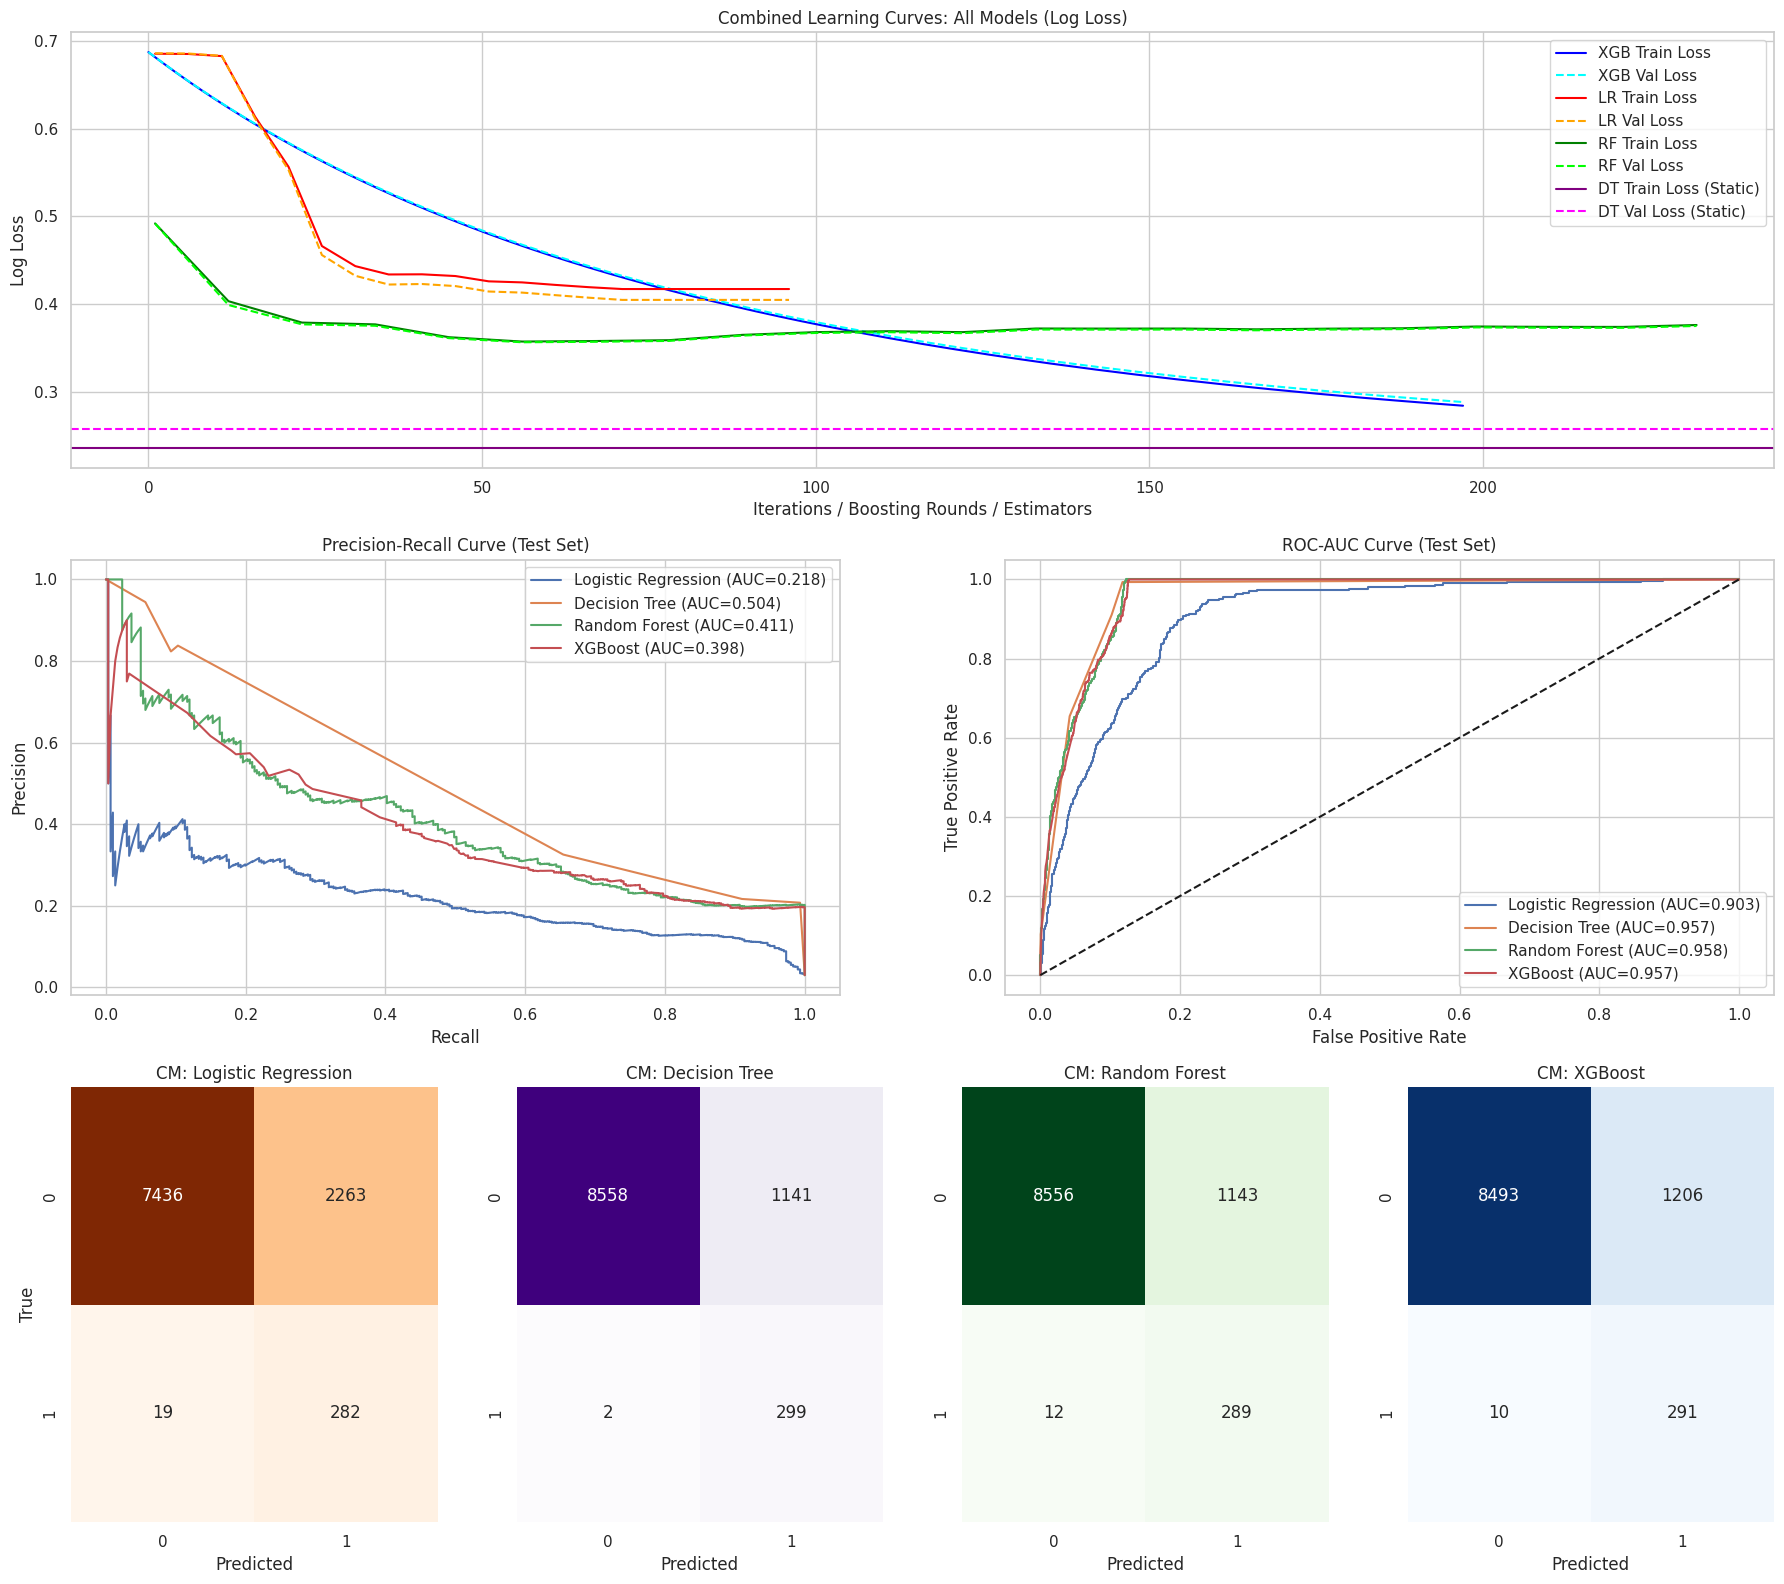

In [ ]:
accuracy_based_baselines(c1_train_data, c1_val_data, c1_test_data)

#### Insurance cost based models

In [ ]:
import optuna
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, roc_auc_score)

def cost_optimized_baselines(train_data, val_data, test_data):
    # --- Configuration ---
    TARGET = 'fraud_label'
    SUM_INSURED = 'sum_insured'

    COST_TP = 100  # Human investigation cost for caught fraud
    COST_FP = 150  # Wasted investigation + reputation damage
    COST_TN = 0    # No action, no cost

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    warnings.filterwarnings("ignore", category=UserWarning)

    # --- Data Preparation ---
    y_train, si_train = train_data[TARGET].values, train_data[SUM_INSURED].values
    y_val, si_val     = val_data[TARGET].values, val_data[SUM_INSURED].values
    y_test, si_test   = test_data[TARGET].values, test_data[SUM_INSURED].values

    X_train = train_data.drop(columns=[TARGET, SUM_INSURED])
    X_val   = val_data.drop(columns=[TARGET, SUM_INSURED])
    X_test  = test_data.drop(columns=[TARGET, SUM_INSURED])

    # --- Core Business Logic ---
    def compute_business_cost(y_true, y_pred_proba, sum_insured_vals, threshold):
        y_pred = (y_pred_proba >= threshold).astype(int)
        cost = np.zeros(len(y_true), dtype=np.float64)

        tp_mask = (y_pred == 1) & (y_true == 1)
        cost[tp_mask] = COST_TP

        fp_mask = (y_pred == 1) & (y_true == 0)
        cost[fp_mask] = COST_FP

        fn_mask = (y_pred == 0) & (y_true == 1)
        cost[fn_mask] = 0.9 * np.maximum(sum_insured_vals[fn_mask], 0)

        return float(np.sum(cost))

    def make_sample_weights(y_true, sum_insured_vals):
        weights = np.where(
            y_true == 1,
            0.9 * np.maximum(sum_insured_vals, 0),
            COST_FP
        ).astype(np.float64)

        weights = np.maximum(weights, 1e-6)
        return weights / weights.mean()

    sw_train = make_sample_weights(y_train, si_train)

    # --- Logistic Regression Tuning ---
    def objective_lr(trial):
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = LogisticRegression(C=C, solver=solver, max_iter=1000, random_state=42)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_lr = optuna.create_study(direction='minimize')
    study_lr.optimize(objective_lr, n_trials=15)
    best_lr_params = study_lr.best_params.copy()
    lr_opt_thresh = best_lr_params.pop('threshold')

    # --- Decision Tree Tuning ---
    def objective_dt(trial):
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_dt = optuna.create_study(direction='minimize')
    study_dt.optimize(objective_dt, n_trials=15)
    best_dt_params = study_dt.best_params.copy()
    dt_opt_thresh = best_dt_params.pop('threshold')

    # --- Random Forest Tuning ---
    def objective_rf(trial):
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 15)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                       min_samples_split=min_samples_split, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train, sample_weight=sw_train)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_rf = optuna.create_study(direction='minimize')
    study_rf.optimize(objective_rf, n_trials=15)
    best_rf_params = study_rf.best_params.copy()
    rf_opt_thresh = best_rf_params.pop('threshold')

    # --- XGBoost Tuning ---
    def objective_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'random_state': 42,
            'eval_metric': 'logloss'
        }
        threshold = trial.suggest_float('threshold', 0.05, 0.95)

        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, sample_weight=sw_train, verbose=False)

        probs = model.predict_proba(X_val)[:, 1]
        cost = compute_business_cost(y_val, probs, si_val, threshold)
        return cost / len(y_val)

    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(objective_xgb, n_trials=15)
    best_xgb_params = study_xgb.best_params.copy()
    xgb_opt_thresh = best_xgb_params.pop('threshold')


    # --- Train Final Models & Evaluate ---

    # 1. Final Logistic Regression
    final_lr = LogisticRegression(**best_lr_params, max_iter=1000, random_state=42)
    final_lr.fit(X_train, y_train, sample_weight=sw_train)
    lr_test_probs = final_lr.predict_proba(X_test)[:, 1]
    lr_test_preds = (lr_test_probs >= lr_opt_thresh).astype(int)
    lr_test_cost = compute_business_cost(y_test, lr_test_probs, si_test, lr_opt_thresh)

    # 2. Final Decision Tree
    final_dt = DecisionTreeClassifier(**best_dt_params, random_state=42)
    final_dt.fit(X_train, y_train, sample_weight=sw_train)
    dt_test_probs = final_dt.predict_proba(X_test)[:, 1]
    dt_test_preds = (dt_test_probs >= dt_opt_thresh).astype(int)
    dt_test_cost = compute_business_cost(y_test, dt_test_probs, si_test, dt_opt_thresh)

    # 3. Final Random Forest
    final_rf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
    final_rf.fit(X_train, y_train, sample_weight=sw_train)
    rf_test_probs = final_rf.predict_proba(X_test)[:, 1]
    rf_test_preds = (rf_test_probs >= rf_opt_thresh).astype(int)
    rf_test_cost = compute_business_cost(y_test, rf_test_probs, si_test, rf_opt_thresh)

    # 4. Final XGBoost
    final_xgb = xgb.XGBClassifier(**best_xgb_params, random_state=42, eval_metric='logloss')
    final_xgb.fit(X_train, y_train, sample_weight=sw_train, verbose=False)
    xgb_test_probs = final_xgb.predict_proba(X_test)[:, 1]
    xgb_test_preds = (xgb_test_probs >= xgb_opt_thresh).astype(int)
    xgb_test_cost = compute_business_cost(y_test, xgb_test_probs, si_test, xgb_opt_thresh)

    # --- Calculate Traditional Metrics ---
    def get_metrics_dict(preds, probs):
        return {
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall': recall_score(y_test, preds, zero_division=0),
            'F1-Score': f1_score(y_test, preds, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, probs)
        }

    metrics_data = {
        'Logistic Regression': get_metrics_dict(lr_test_preds, lr_test_probs),
        'Decision Tree': get_metrics_dict(dt_test_preds, dt_test_probs),
        'Random Forest': get_metrics_dict(rf_test_preds, rf_test_probs),
        'XGBoost': get_metrics_dict(xgb_test_preds, xgb_test_probs)
    }

    # --- Compile Final Financial Results ---
    def create_result_row(model_name, thresh, cost, probs, preds):
        return {
            'Model': model_name,
            'Opt_Threshold': thresh,
            'Cost / Row': cost / len(y_test),
            'Total Cost (Test)': cost,
            **metrics_data[model_name]
        }

    results_df = pd.DataFrame([
        create_result_row('Logistic Regression', lr_opt_thresh, lr_test_cost, lr_test_probs, lr_test_preds),
        create_result_row('Decision Tree', dt_opt_thresh, dt_test_cost, dt_test_probs, dt_test_preds),
        create_result_row('Random Forest', rf_opt_thresh, rf_test_cost, rf_test_probs, rf_test_preds),
        create_result_row('XGBoost', xgb_opt_thresh, xgb_test_cost, xgb_test_probs, xgb_test_preds)
    ])

    print("\n--- Final Test Set Financial & Statistical Performance ---")
    try:
        display(results_df)
    except NameError:
        print(results_df.to_string())

    # --- Visualizations ---
    fig = plt.figure(figsize=(18, 16))
    sns.set_theme(style="whitegrid")

    # 1. Cost vs Threshold Sweep (Top Row)
    ax1 = plt.subplot(3, 1, 1)
    thresholds_plot = np.linspace(0.01, 0.99, 99)

    lr_costs = [compute_business_cost(y_test, lr_test_probs, si_test, t) for t in thresholds_plot]
    dt_costs = [compute_business_cost(y_test, dt_test_probs, si_test, t) for t in thresholds_plot]
    rf_costs = [compute_business_cost(y_test, rf_test_probs, si_test, t) for t in thresholds_plot]
    xgb_costs = [compute_business_cost(y_test, xgb_test_probs, si_test, t) for t in thresholds_plot]

    ax1.plot(thresholds_plot, lr_costs, label='Logistic Regression Cost', color='orange', linewidth=2)
    ax1.plot(thresholds_plot, dt_costs, label='Decision Tree Cost', color='purple', linewidth=2)
    ax1.plot(thresholds_plot, rf_costs, label='Random Forest Cost', color='green', linewidth=2)
    ax1.plot(thresholds_plot, xgb_costs, label='XGBoost Cost', color='blue', linewidth=2)

    ax1.axvline(lr_opt_thresh, color='orange', linestyle='--', alpha=0.7, label=f'LR Thresh: {lr_opt_thresh:.2f}')
    ax1.axvline(dt_opt_thresh, color='purple', linestyle='--', alpha=0.7, label=f'DT Thresh: {dt_opt_thresh:.2f}')
    ax1.axvline(rf_opt_thresh, color='green', linestyle='--', alpha=0.7, label=f'RF Thresh: {rf_opt_thresh:.2f}')
    ax1.axvline(xgb_opt_thresh, color='blue', linestyle='--', alpha=0.7, label=f'XGB Thresh: {xgb_opt_thresh:.2f}')

    ax1.scatter([lr_opt_thresh, dt_opt_thresh, rf_opt_thresh, xgb_opt_thresh],
                [lr_test_cost, dt_test_cost, rf_test_cost, xgb_test_cost],
                color=['orange', 'purple', 'green', 'blue'], s=100, zorder=5)

    ax1.set_title('Financial Impact: Total Portfolio Cost vs. Classification Threshold', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Probability Threshold')
    ax1.set_ylabel('Total Cost Incurred ($)')
    ax1.legend(loc='upper right', ncol=2)

    # 2. Confusion Matrices (Middle Row - 4 across)
    model_configs = [
        (lr_test_preds, lr_opt_thresh, 'Oranges', 'LR'),
        (dt_test_preds, dt_opt_thresh, 'Purples', 'DT'),
        (rf_test_preds, rf_opt_thresh, 'Greens', 'RF'),
        (xgb_test_preds, xgb_opt_thresh, 'Blues', 'XGBoost')
    ]

    for i, (preds, thresh, cmap, name) in enumerate(model_configs):
        ax = plt.subplot(3, 4, 5 + i)
        sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False)
        ax.set_title(f'Cost-Weighted {name}\n(Thresh: {thresh:.2f})')
        ax.set_xlabel('Predicted')
        if i == 0:
            ax.set_ylabel('True')

    # 3. Traditional Metrics Comparison (Bottom Row)
    ax3 = plt.subplot(3, 1, 3)
    metrics_labels = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']

    lr_scores = [metrics_data['Logistic Regression'][m] for m in metrics_labels]
    dt_scores = [metrics_data['Decision Tree'][m] for m in metrics_labels]
    rf_scores = [metrics_data['Random Forest'][m] for m in metrics_labels]
    xgb_scores = [metrics_data['XGBoost'][m] for m in metrics_labels]

    x = np.arange(len(metrics_labels))
    width = 0.2  # Thinner bars to fit 4 groups

    bars1 = ax3.bar(x - 1.5*width, lr_scores, width, label='Logistic Regression', color='orange', alpha=0.8)
    bars2 = ax3.bar(x - 0.5*width, dt_scores, width, label='Decision Tree', color='purple', alpha=0.8)
    bars3 = ax3.bar(x + 0.5*width, rf_scores, width, label='Random Forest', color='green', alpha=0.8)
    bars4 = ax3.bar(x + 1.5*width, xgb_scores, width, label='XGBoost', color='blue', alpha=0.8)

    ax3.set_title('Traditional Metrics Comparison (Calculated at Optimal Threshold)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Score')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics_labels)
    ax3.set_ylim(0, 1.15)
    ax3.legend(ncol=4, loc='upper center')

    # Add text labels above bars
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            yval = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


--- Final Test Set Financial & Statistical Performance ---


,Model,Opt_Threshold,Cost / Row,Total Cost (Test),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.838510,148.49500,1484950.0,0.030100,1.000000,0.058441,0.505815
1,Decision Tree,0.346339,70.58840,705884.0,0.205781,0.993355,0.340935,0.940353
2,Random Forest,0.297031,104.79583,1047958.3,0.181486,0.990033,0.306742,0.945694
3,XGBoost,0.939554,173.04178,1730417.8,0.208924,0.980066,0.344425,0.964505


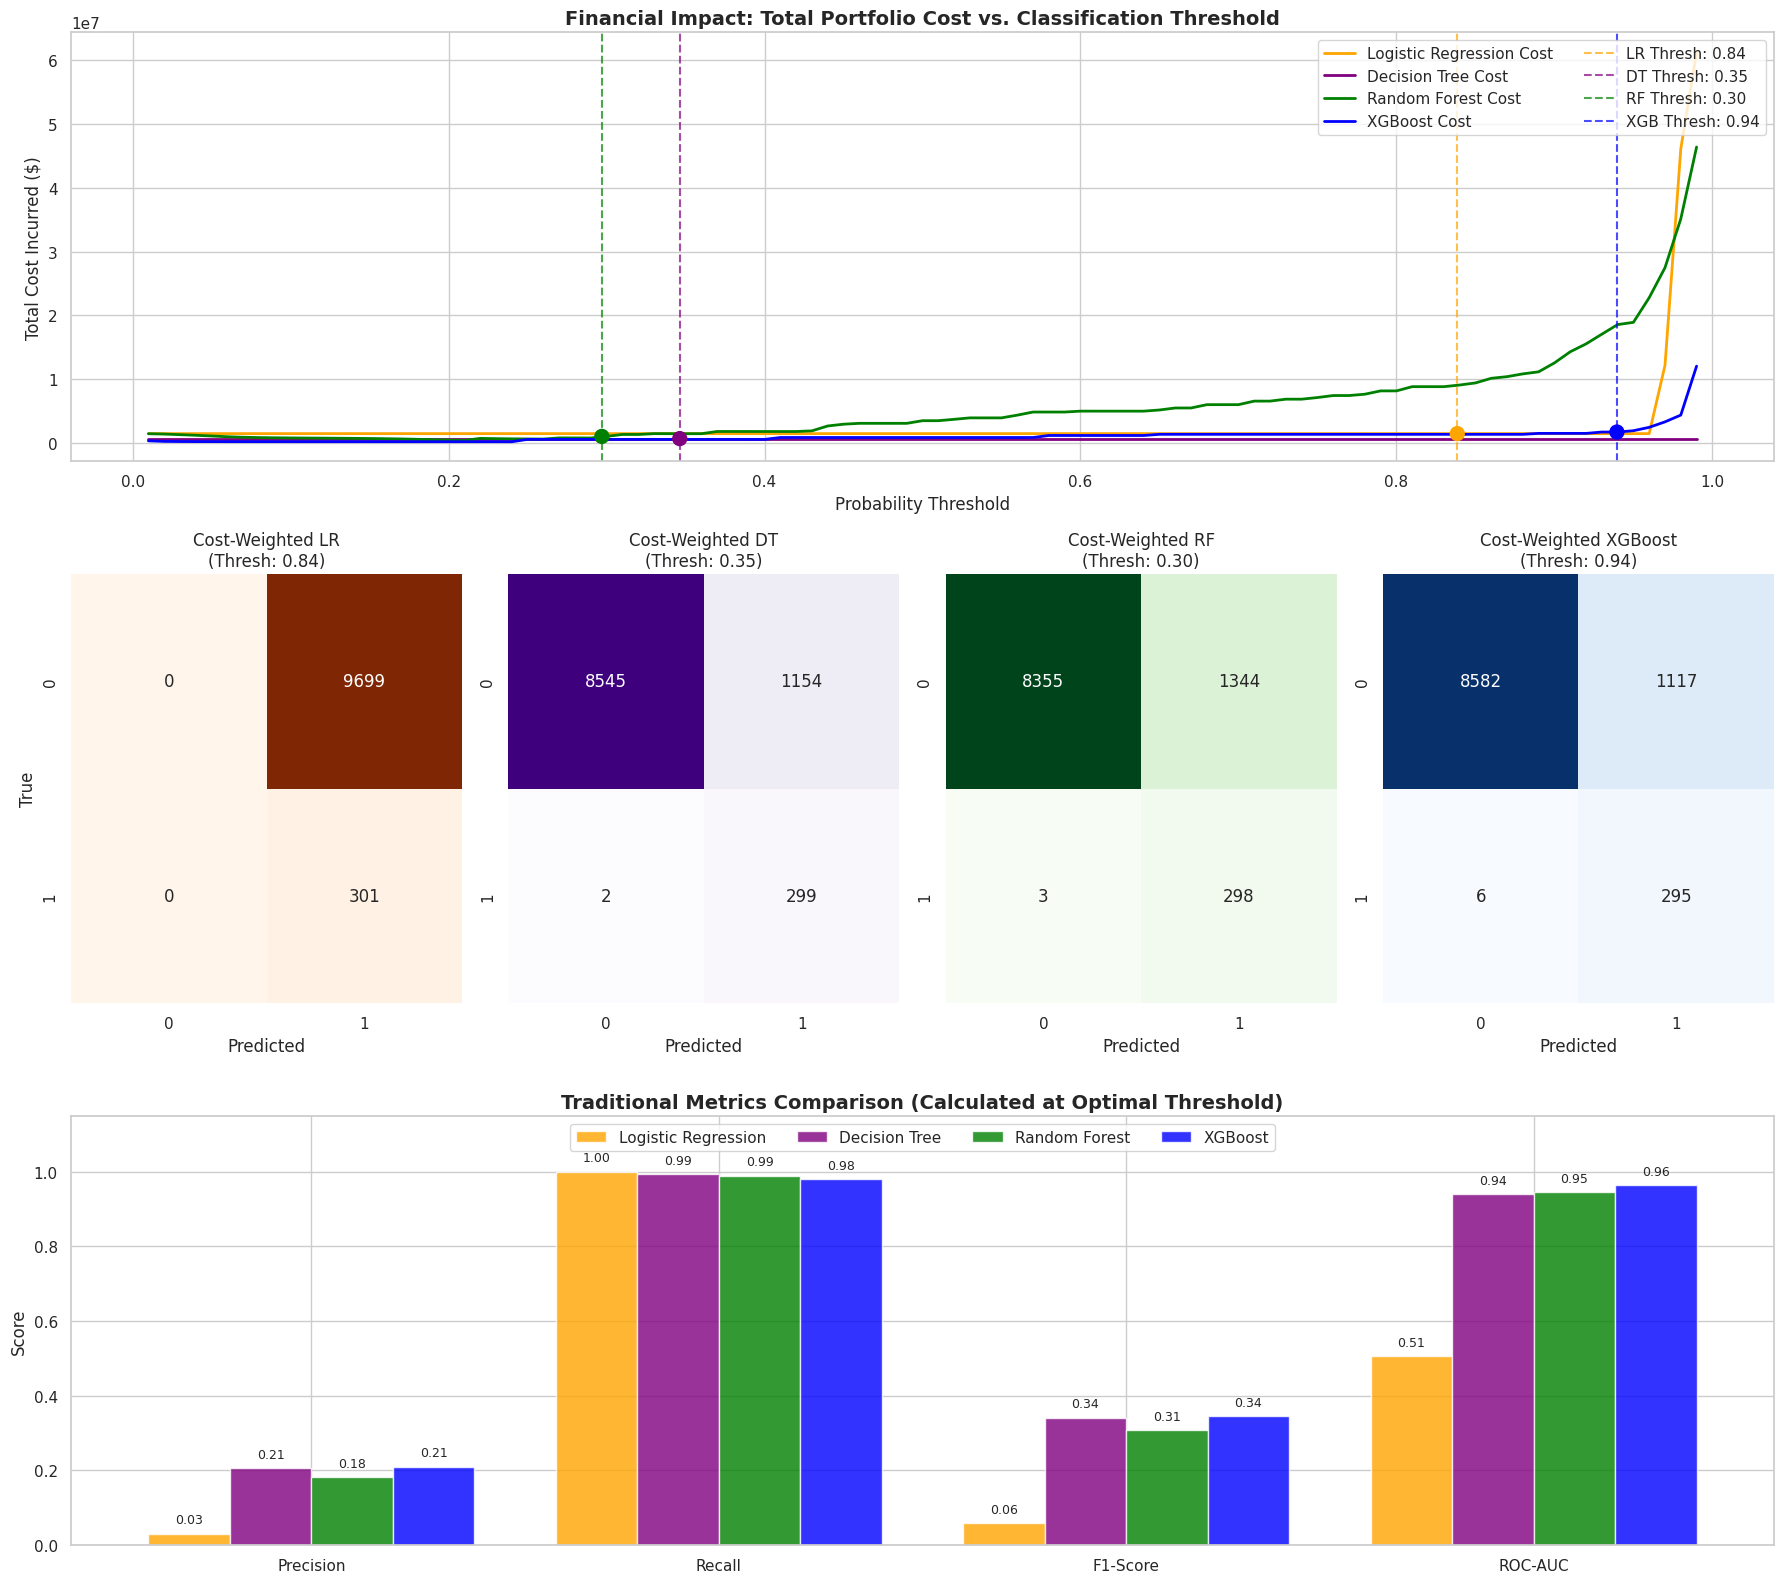

In [ ]:
cost_optimized_baselines(c1_train_data, c1_val_data, c1_test_data)

### Case 2: Train (45k) and val (20k) from labeled, while Test (10k) from unlabled set

In [ ]:
c2_train_data, c2_val_data = train_test_split(df_labeled, test_size=20000, random_state=42, stratify=df_labeled['fraud_label'])
c2_test_data, df_remaining_unlabeled = train_test_split(df_unlabeled, train_size=10000, stratify=df_unlabeled['fraud_label'], random_state=42)

#### Accuracy based models

Best LR Params: {'C': 0.660605378938242, 'solver': 'liblinear'}
Best DT Params: {'max_depth': 6, 'min_samples_split': 15}
Best RF Params: {'n_estimators': 75, 'max_depth': 5, 'min_samples_split': 8}
Best XGB Params: {'n_estimators': 115, 'max_depth': 3, 'learning_rate': 0.06181665129888664, 'subsample': 0.7577715047338891}

--- Final Test Set Performance ---


,Model,ROC-AUC,F1-Score,Precision,Recall
0,Logistic Regression,0.897624,0.194435,0.108704,0.920000
1,Decision Tree,0.960261,0.340909,0.205479,1.000000
2,Random Forest,0.951370,0.324719,0.195270,0.963333
3,XGBoost,0.956589,0.321951,0.192233,0.990000


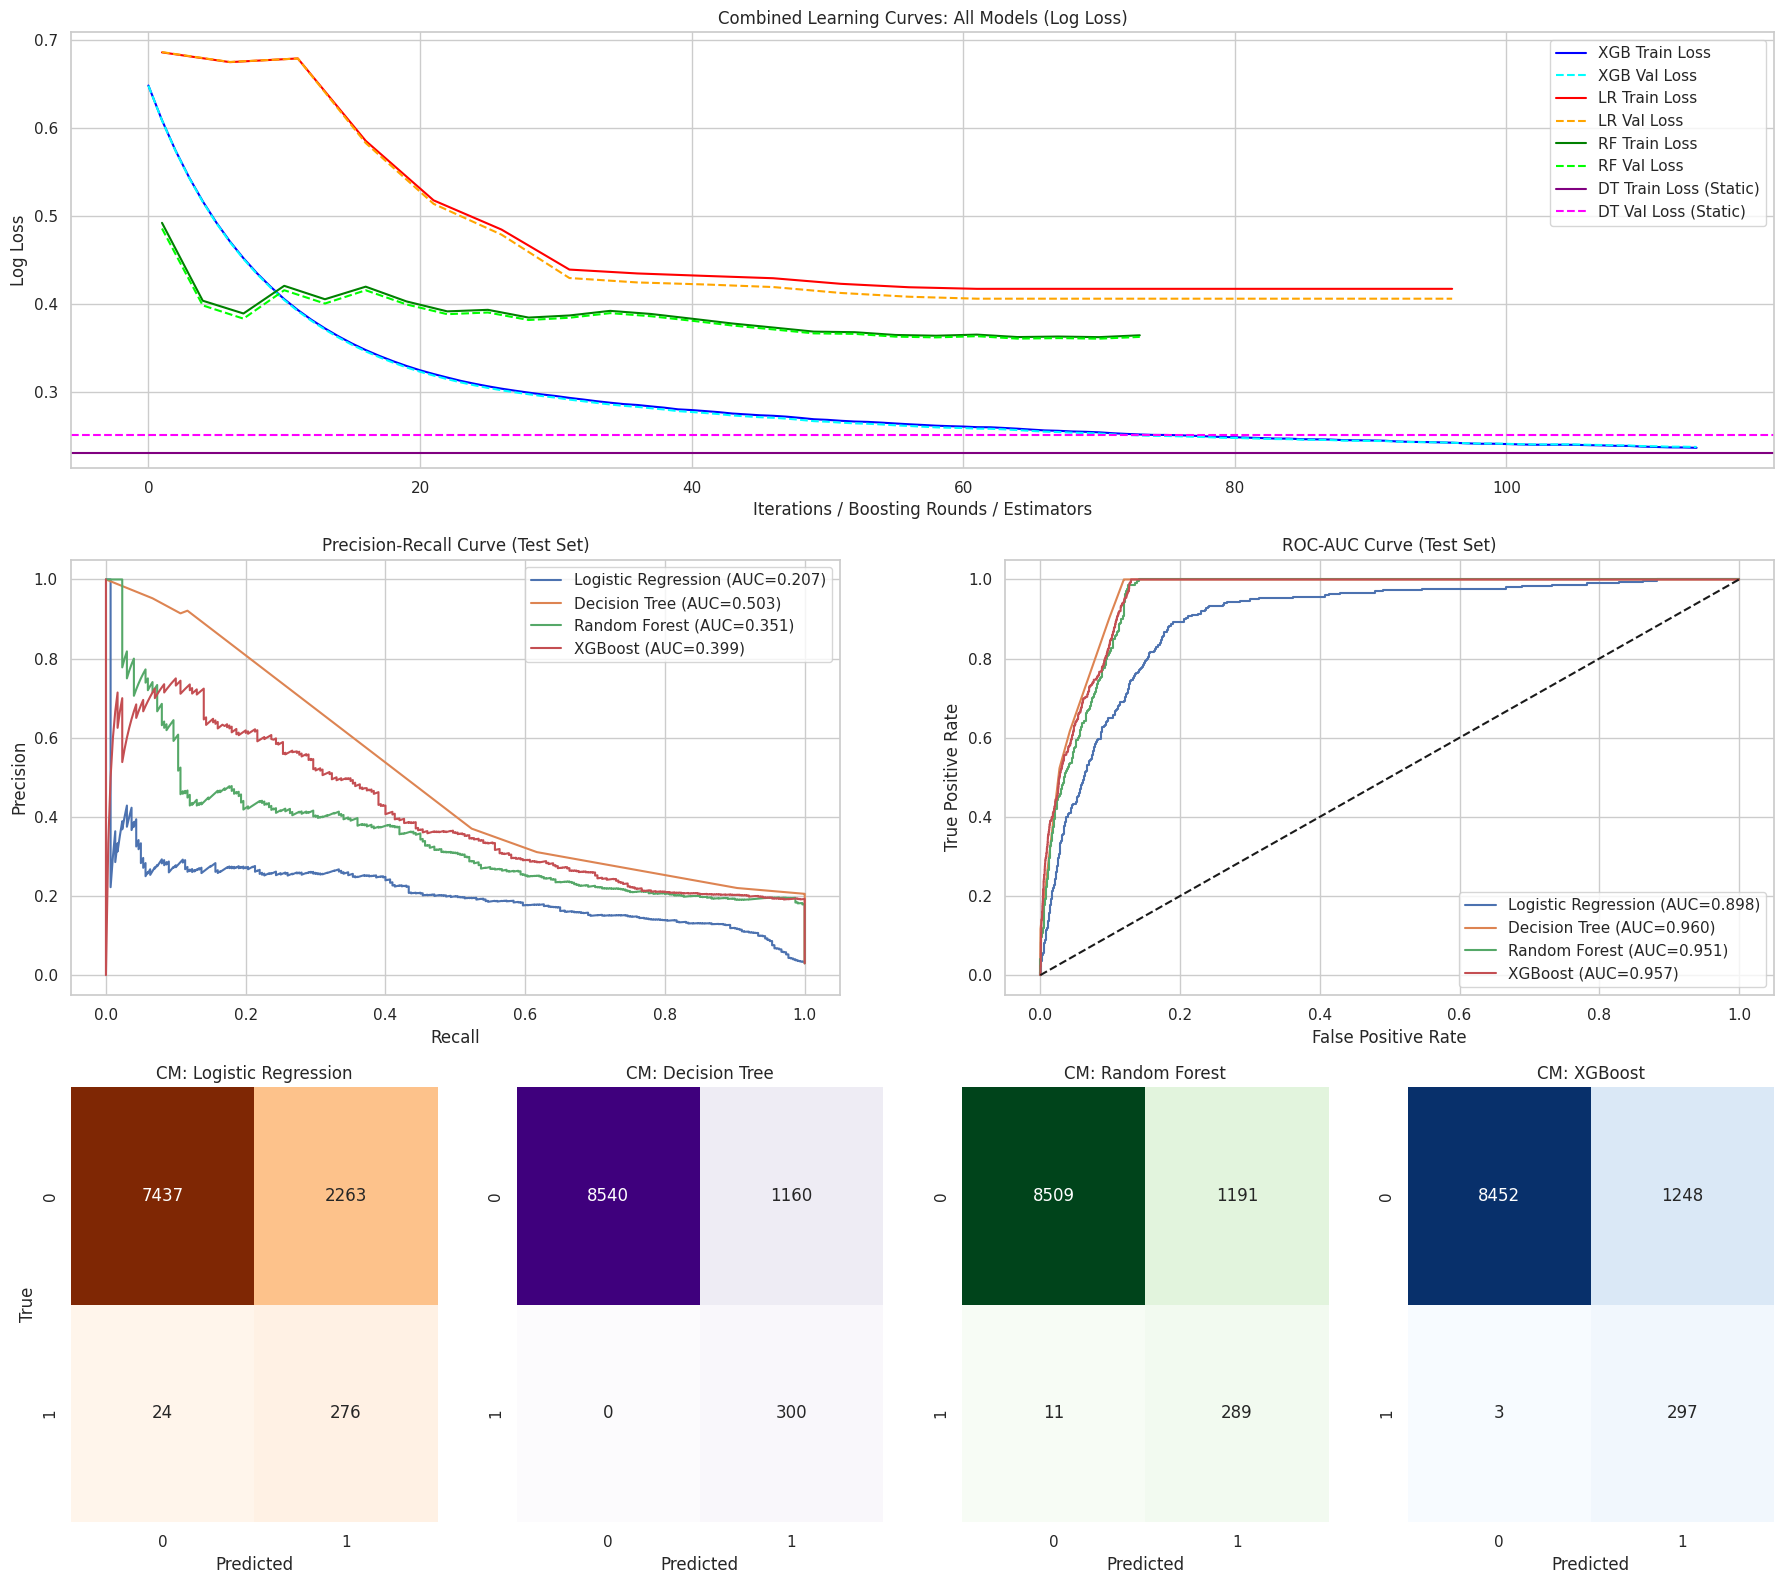

In [ ]:
accuracy_based_baselines(c2_train_data, c2_val_data, c2_test_data)

#### Insurance cost based models


--- Final Test Set Financial & Statistical Performance ---


,Model,Opt_Threshold,Cost / Row,Total Cost (Test),Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.310748,148.500,1485000.0,0.030000,1.0,0.058252,0.506235
1,Decision Tree,0.675586,42.750,427500.0,0.101695,1.0,0.184615,0.935939
2,Random Forest,0.343953,47.400,474000.0,0.092025,1.0,0.168539,0.943663
3,XGBoost,0.428643,22.245,222450.0,0.189514,1.0,0.318640,0.954396


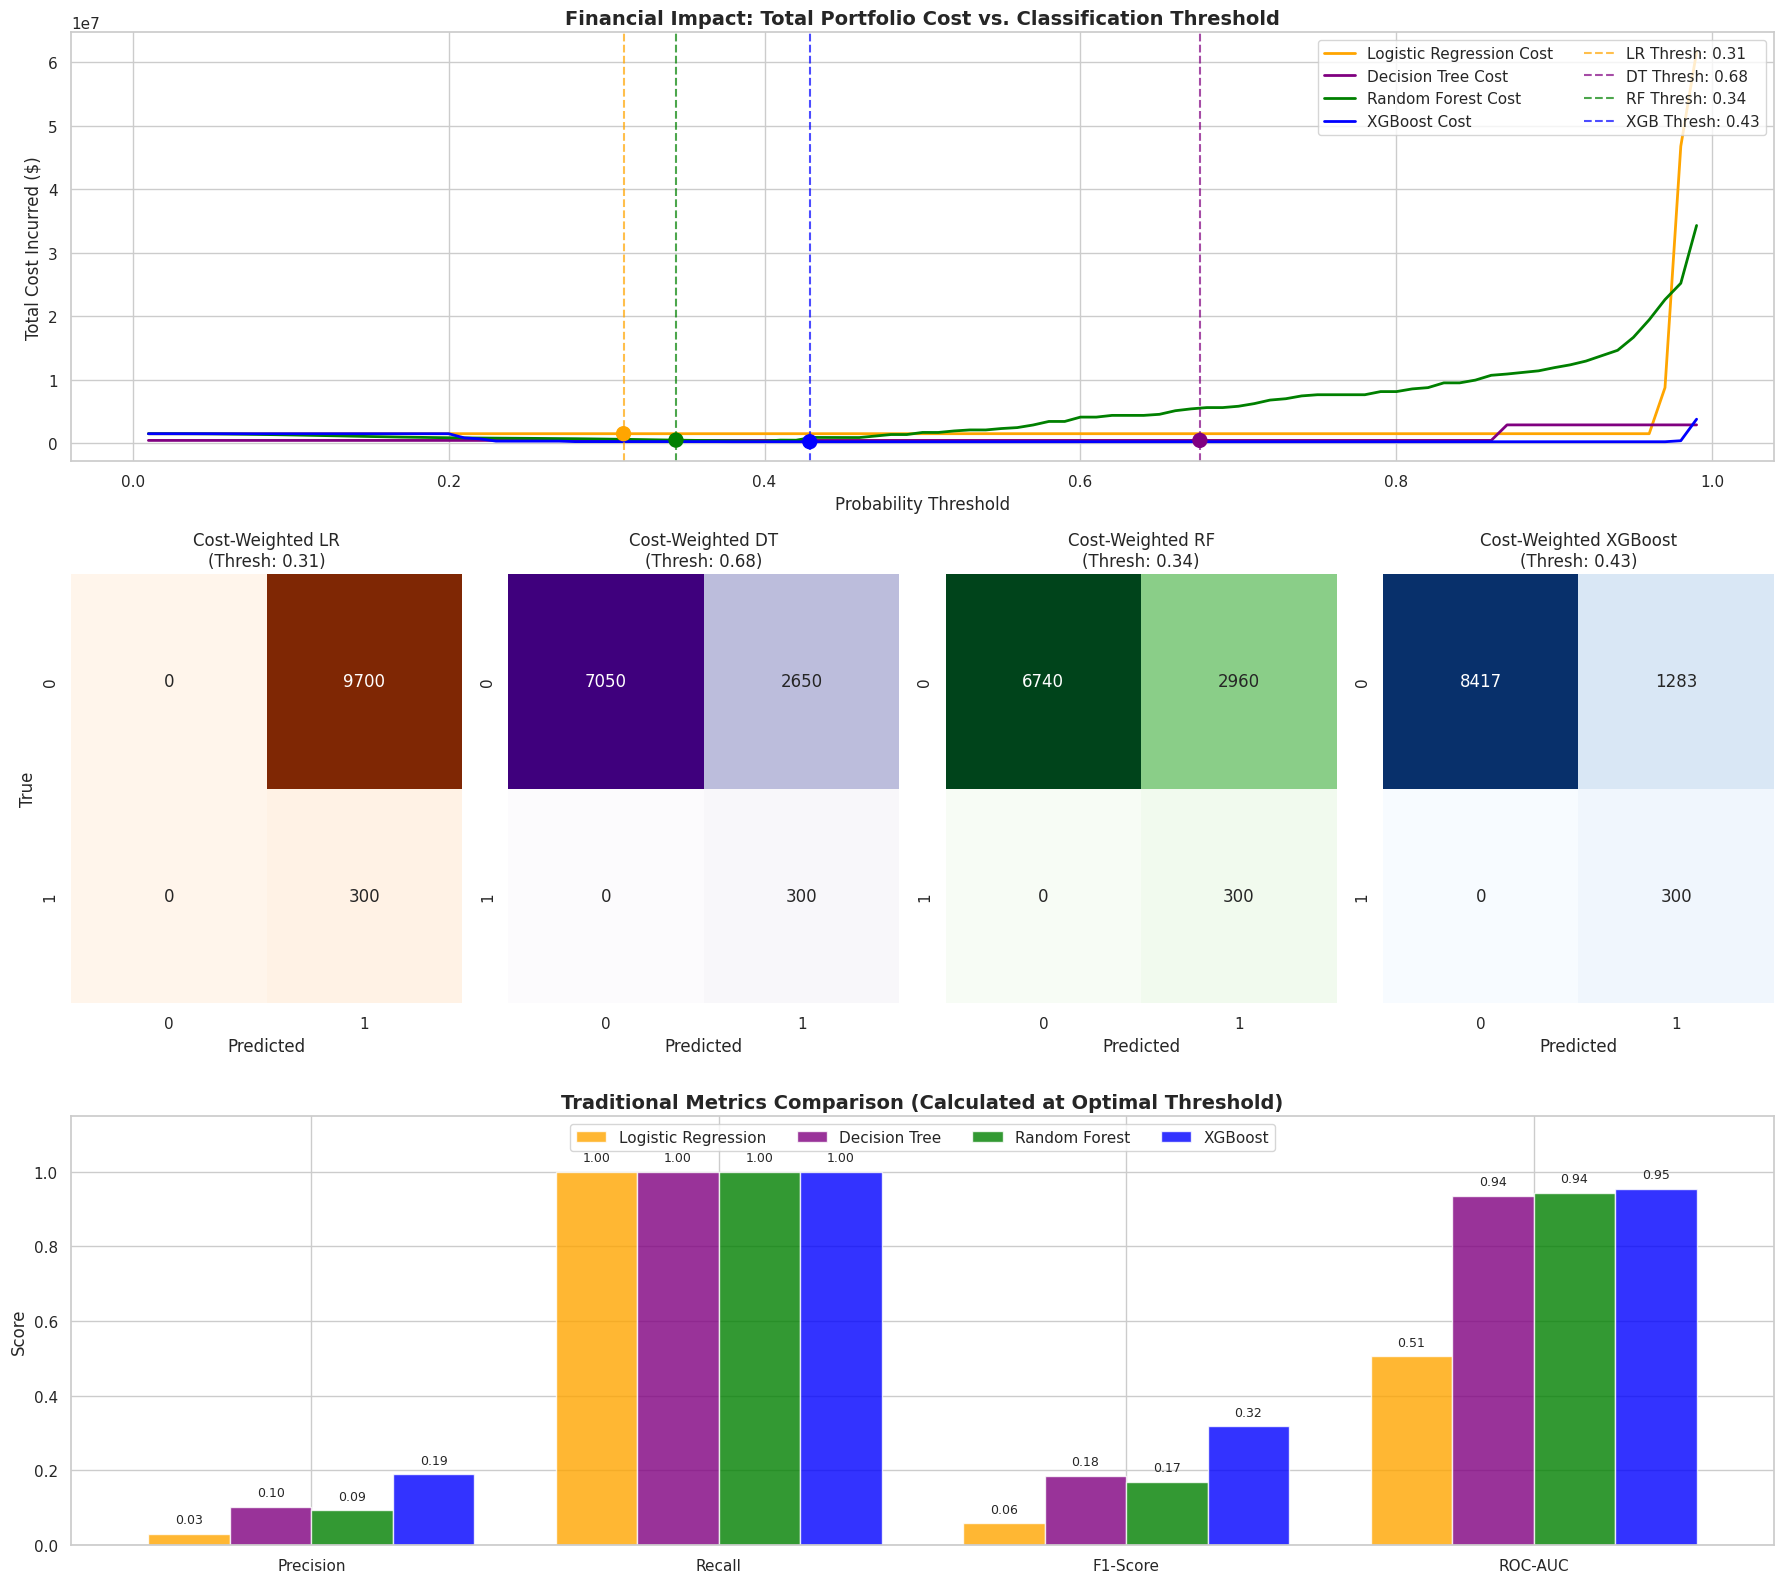

In [ ]:
cost_optimized_baselines(c2_train_data, c2_val_data, c2_test_data)

## Grid-search

Took '-1' in sum_insured as a feature that the model has to learn. '-1' is replaced by '0' when calculating the cost weighted loss

[1/4] Loading data …
    Total rows   : 95,000
    Train (CV)   : 45,000 | Fraud 3.0%
    Val (ES)     : 10,000   | Fraud 3.0%
    Test (final) : 10,000  | Fraud 3.0%
    Features     : 42
[2/4] Starting Optuna search — 5 trials, 5-fold CV …
  ────────────────────────────────────────────────────────────

  Trial   0 | thresh=0.069 | lr=0.0580 | depth=5 | n_est=1475
    Fold 1/5 | cost/row=48.4667 | running mean=48.4667 | best_round=1238
    Fold 2/5 | cost/row=46.2833 | running mean=47.3750 | best_round=764
    Fold 3/5 | cost/row=49.1500 | running mean=47.9667 | best_round=724
    Fold 4/5 | cost/row=50.3667 | running mean=48.5667 | best_round=728
    Fold 5/5 | cost/row=49.5444 | running mean=48.7622 | best_round=628

  ── Trial   0 [OK] cv_cost/row=48.7622 | best_so_far=48.7622 ◀ best
  ────────────────────────────────────────────────────────────

  Trial   1 | thresh=0.176 | lr=0.0105 | depth=9 | n_est=1301
    Fold 1/5 | cost/row=148.5000 | running mean=148.5000 | best_round=1
   

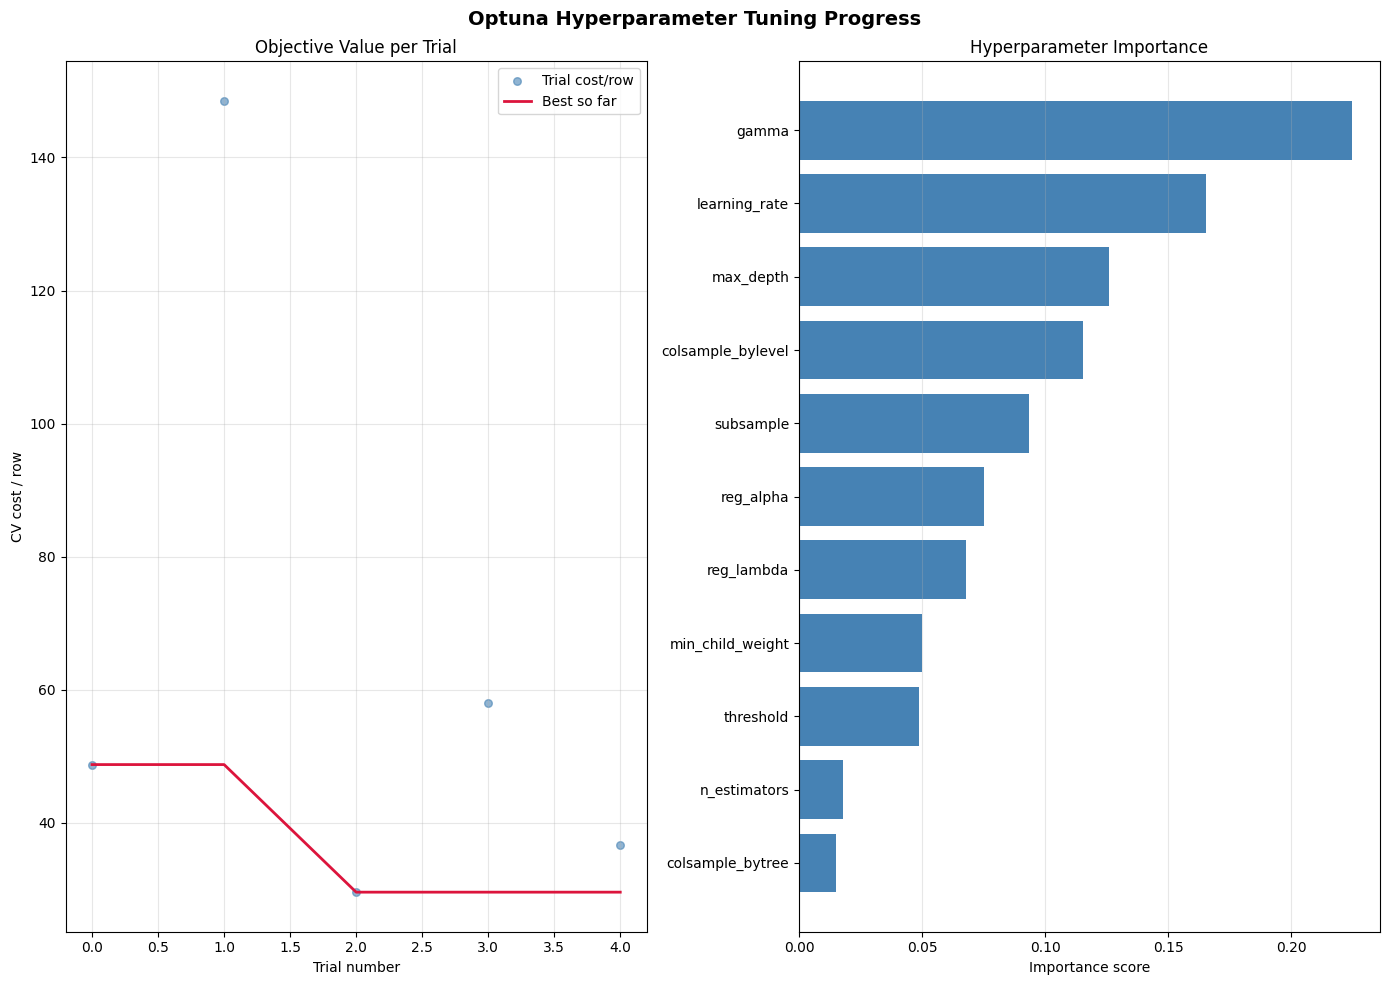

Plot saved → 'optuna_progress.png'
[4/4] Evaluating best params on held-out test set …

── Final Test Set Results ─────────────────────────────
  Threshold            : 0.1085
  Best boost round     : 237
  Total business cost  : 225,250.00
  Cost per row         : 22.5250
  TP / FP / TN / FN   : 301 / 1301 / 8398 / 0
  Precision            : 0.1879
  Recall               : 1.0000
  F1                   : 0.3163
───────────────────────────────────────────────────────

Best params saved → 'best_params.json'


In [ ]:
# ============================================================
#  XGBoost Fraud Detection — Optuna Tuner
#  Run this single cell. Edit the CONFIG block at the top.
# ============================================================

# ╔══════════════════════════════════════════════════════════╗
# ║                    USER CONFIG                           ║
# ╚══════════════════════════════════════════════════════════╝

TARGET_COL          = "fraud_label"     # column name: 1 = fraud, 0 = not fraud
SUM_INSURED_COL     = "sum_insured"     # column name holding the insured amount per row

COST_TP             = 100              # model says fraud (1), actually fraud (1)     → investigation cost
COST_FP             = 150              # model says fraud (1), actually not fraud (0) → false alarm cost + reputation damage
COST_TN             = 0               # model says not fraud (0), actually not fraud  → no cost (fixed)
# COST_FN             = 0.9 * sum_insured  per row (missed fraud = pay out 90% of claim)

TEST_SIZE           = 0.15            # fraction of data held out as final test set (never seen during tuning)
VAL_SIZE            = 0.15            # fraction of data held out as Optuna validation set (early stopping only)
                                      # remaining ~70% is used for CV inside Optuna
N_TRIALS            = 5              # number of Optuna search trials (more = better, slower)
N_FOLDS             = 5               # cross-validation folds (stratified by fraud label)
EARLY_STOPPING      = 50              # stop boosting if val business cost doesn't improve for this many rounds
N_WARMUP_STEPS      = 10              # trials before Optuna starts pruning weak trials
RANDOM_STATE        = 42
OUTPUT_JSON         = "best_params.json"  # where to save the best hyperparameters


# ╔══════════════════════════════════════════════════════════╗
# ║                    IMPORTS                               ║
# ╚══════════════════════════════════════════════════════════╝

import json
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ╔══════════════════════════════════════════════════════════╗
# ║             STEP 1 — LOAD, VALIDATE & SPLIT DATA         ║
# ╚══════════════════════════════════════════════════════════╝

print("[1/4] Loading data …")


# ── encode categorical columns so XGBoost can handle them ────
X_raw_train = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_all_train = c1_train_data[TARGET_COL].values.astype(np.int32)
si_all_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)


X_raw_val = c1_val_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_all_val = c1_val_data[TARGET_COL].values.astype(np.int32)
si_all_val = c1_val_data[SUM_INSURED_COL].values.astype(np.float64)

X_raw_test = c1_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_all_test = c1_test_data[TARGET_COL].values.astype(np.int32)
si_all_test = c1_test_data[SUM_INSURED_COL].values.astype(np.float64)


for col in X_raw_train.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    X_raw_train[col] = le.fit_transform(X_raw_train[col].astype(str))

for col in X_raw_val.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    X_raw_val[col] = le.fit_transform(X_raw_val[col].astype(str))

for col in X_raw_test.select_dtypes(include=["object", "category"]).columns:
    le = LabelEncoder()
    X_raw_test[col] = le.fit_transform(X_raw_test[col].astype(str))

# ── 1. carve out held-out TEST set (never used during tuning) ─
X_test  = X_raw_test.copy()
y_test  = y_all_test
si_test  = si_all_test


# ── 2. carve out VALIDATION set (used only for early stopping) ─
X_train = X_raw_train.copy()
X_val   = X_raw_val.copy()

y_train = y_all_train
y_val   = y_all_val

si_train = si_all_train
si_val   = si_all_val

# ── 3. the remaining X_train / y_train is used for CV inside Optuna ─
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)  # class imbalance ratio (train only)

print(f"    Total rows   : {len(df):,}")
print(f"    Train (CV)   : {len(X_train):,} | Fraud {np.mean(y_train)*100:.1f}%")
print(f"    Val (ES)     : {len(X_val):,}   | Fraud {np.mean(y_val)*100:.1f}%")
print(f"    Test (final) : {len(X_test):,}  | Fraud {np.mean(y_test)*100:.1f}%")
print(f"    Features     : {X_train.shape[1]}")


# ╔══════════════════════════════════════════════════════════╗
# ║          STEP 2 — CUSTOM BUSINESS COST FUNCTION          ║
# ╚══════════════════════════════════════════════════════════╝

def compute_business_cost(y_true, y_pred_proba, sum_insured_vals,
                           threshold=0.5,
                           cost_tp=COST_TP,
                           cost_fp=COST_FP):
    """Lower is better. Returns total cost over the provided split."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    cost = np.zeros(len(y_true), dtype=np.float64)

    tp_mask = (y_pred == 1) & (y_true == 1)
    cost[tp_mask] = cost_tp                                         # investigation cost

    fp_mask = (y_pred == 1) & (y_true == 0)
    cost[fp_mask] = cost_fp                                         # false alarm cost

    fn_mask = (y_pred == 0) & (y_true == 1)
    cost[fn_mask] = 0.9 * np.maximum(sum_insured_vals[fn_mask], 0) # missed fraud → pay 90% of claim

    # cost_tn = 0 (no entry needed)
    return float(np.sum(cost))


def make_sample_weights(y_train_fold, si_train_fold):
    """
    Weight each training sample by its expected cost contribution.
    Fraud samples  → weighted by the payout we'd miss (0.9 * sum_insured).
    Non-fraud      → weighted by the false-alarm cost (COST_FP).
    scale_pos_weight is NOT used alongside these weights to avoid double-counting.
    """
    weights = np.where(
        y_train_fold == 1,
        0.9 * np.maximum(si_train_fold, 0),
        COST_FP
    ).astype(np.float64)
    weights = np.maximum(weights, 1e-6)   # XGBoost requires strictly positive weights
    weights = weights / weights.mean()    # normalise so mean weight ≈ 1
    return weights


def business_cost_custom_metric(y_proba, dtrain, si_vals, threshold):
    """
    XGBoost custom metric callback.
    Returns (metric_name, value) — lower is better (maximize=False).
    Normalises by number of rows so folds of different sizes are comparable.
    """
    y_true = dtrain.get_label()
    cost = compute_business_cost(y_true, y_proba, si_vals, threshold=threshold)
    return "business_cost", cost / max(len(y_true), 1)

# ╔══════════════════════════════════════════════════════════╗
# ║          STEP 3 — OPTUNA OBJECTIVE FUNCTION              ║
# ╚══════════════════════════════════════════════════════════╝
#
#  Architecture:
#    • Outer loop  → N_FOLDS stratified CV on X_train / y_train
#    • Inner early-stopping → uses the *held-out* X_val / y_val (not the CV fold)
#      This ensures early stopping is consistent across folds and doesn't leak
#      information between CV folds.
#    • Pruning     → trial.report() called AFTER each complete fold so Optuna
#      prunes based on real fold costs, not partial accumulations.
# ╚══════════════════════════════════════════════════════════╝

def objective(trial):
    params = {
        "objective":         "binary:logistic",
        "tree_method":       "hist",
        "seed":              RANDOM_STATE,
        "max_depth":         trial.suggest_int("max_depth", 3, 9),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0.0, 1.0),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 2.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
        # scale_pos_weight intentionally omitted — sample weights handle class imbalance
    }
    n_estimators = trial.suggest_int("n_estimators", 200, 2000)
    threshold    = trial.suggest_float("threshold", 0.05, 0.95)

    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_costs = []

    # Pre-build the early-stopping DMatrix (same for all folds — consistent signal)
    sw_val_es = make_sample_weights(y_val, si_val)
    dval_es   = xgb.DMatrix(X_val, label=y_val, weight=sw_val_es)

    # ── CHANGE 1: print trial header so you can track fold progress ──────────
    print(f"\n  Trial {trial.number:>3d} | thresh={threshold:.3f} | "
          f"lr={params['learning_rate']:.4f} | depth={params['max_depth']} | "
          f"n_est={n_estimators}")

    for fold, (tr_idx, cv_val_idx) in enumerate(cv.split(X_train, y_train)):

        X_tr  = X_train.iloc[tr_idx]
        y_tr  = y_train[tr_idx]
        si_tr = si_train[tr_idx]

        X_cv_val  = X_train.iloc[cv_val_idx]
        y_cv_val  = y_train[cv_val_idx]
        si_cv_val = si_train[cv_val_idx]

        sw_tr  = make_sample_weights(y_tr, si_tr)
        dtrain = xgb.DMatrix(X_tr,     label=y_tr,     weight=sw_tr)
        dcvval = xgb.DMatrix(X_cv_val, label=y_cv_val)

        # Custom metric closure for early-stopping eval set (held-out val)
        def es_metric(y_pred_raw, dtrain_inner, _si=si_val, _th=threshold):
            return business_cost_custom_metric(y_pred_raw, dtrain_inner, _si, _th)

        booster = xgb.train(
            params,
            dtrain,
            num_boost_round       = n_estimators,
            evals                 = [(dval_es, "val_es")],     # early stopping on held-out val
            custom_metric         = es_metric,
            early_stopping_rounds = EARLY_STOPPING,
            maximize              = False,                      # minimise business cost
            verbose_eval          = False,
        )

        best_round = booster.best_iteration + 1  # best_iteration is 0-indexed

        # Evaluate on the CV fold's own held-out slice (unbiased fold estimate)
        y_proba_cv = booster.predict(dcvval, iteration_range=(0, best_round))
        fold_cost  = compute_business_cost(
            y_true=y_cv_val,
            y_pred_proba=y_proba_cv,
            sum_insured_vals=si_cv_val,
            threshold=threshold,
        )
        fold_cost_per_row = fold_cost / len(y_cv_val) # normalise per-row
        fold_costs.append(fold_cost_per_row)

        # ── CHANGE 1 (cont.): print per-fold cost + running mean ─────────────
        print(f"    Fold {fold+1}/{N_FOLDS} | cost/row={fold_cost_per_row:,.4f} | "
              f"running mean={np.mean(fold_costs):,.4f} | best_round={best_round}")

        trial.report(float(np.mean(fold_costs)), step=fold)
        if trial.should_prune():
            print(f"    ✂  Trial {trial.number} pruned at fold {fold+1}")
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_costs))


# ╔══════════════════════════════════════════════════════════╗
# ║              STEP 4 — RUN OPTUNA                         ║
# ╚══════════════════════════════════════════════════════════╝

# ── CHANGE 2: callback prints a summary line after every completed trial ─────
def optuna_progress_callback(study, trial):
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else "OK"
    value  = trial.value if trial.value is not None else float("nan")
    best   = study.best_value if study.best_trial is not None else float("nan")
    marker = " ◀ best" if (trial.value is not None and trial.value == best) else ""
    print(f"\n  ── Trial {trial.number:>3d} [{status}] "
          f"cv_cost/row={value:,.4f} | best_so_far={best:,.4f}{marker}")
    print(f"  {'─'*60}")

print(f"[2/4] Starting Optuna search — {N_TRIALS} trials, {N_FOLDS}-fold CV …")
print(f"  {'─'*60}")

study = optuna.create_study(
    direction = "minimize",
    pruner    = optuna.pruners.MedianPruner(n_warmup_steps=N_WARMUP_STEPS),
    sampler   = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(
    objective,
    n_trials   = N_TRIALS,
    callbacks  = [optuna_progress_callback],   # ← CHANGE 2: callback added here
)

print(f"[3/4] Optuna finished. Best avg cost/row (CV): {study.best_value:,.4f}")


# ╔══════════════════════════════════════════════════════════╗
# ║          STEP 4b — VISUALISE OPTUNA PROGRESS             ║
# ╚══════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

# ── collect trial data ────────────────────────────────────────
trial_nums   = []
trial_values = []
best_so_far  = []
pruned_nums  = []
running_best = float("inf")

for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trial_nums.append(t.number)
        trial_values.append(t.value)
        running_best = min(running_best, t.value)
        best_so_far.append(running_best)
    elif t.state == optuna.trial.TrialState.PRUNED:
        pruned_nums.append(t.number)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.suptitle("Optuna Hyperparameter Tuning Progress", fontsize=14, fontweight="bold")

# ── Plot 1: cost per trial + best-so-far curve ───────────────
ax = axes[0]
ax.scatter(trial_nums, trial_values, s=30, alpha=0.6, color="steelblue", label="Trial cost/row")
ax.plot(trial_nums, best_so_far, color="crimson", linewidth=2, label="Best so far")
for p in pruned_nums:
    ax.axvline(p, color="orange", alpha=0.3, linewidth=0.8)
ax.set_xlabel("Trial number")
ax.set_ylabel("CV cost / row")
ax.set_title("Objective Value per Trial")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: param importance ──────────────────────────────────
ax = axes[1]
try:
    importances = optuna.importance.get_param_importances(study)
    names  = list(importances.keys())
    values = list(importances.values())
    ax.barh(names[::-1], values[::-1], color="steelblue")
    ax.set_xlabel("Importance score")
    ax.set_title("Hyperparameter Importance")
    ax.grid(True, alpha=0.3, axis="x")
except Exception:
    ax.text(0.5, 0.5, "Not enough trials\nfor importance", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title("Hyperparameter Importance")

plt.tight_layout()
plt.savefig("optuna_progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → 'optuna_progress.png'")

# ╔══════════════════════════════════════════════════════════╗
# ║     STEP 5 — FINAL EVALUATION ON HELD-OUT TEST SET       ║
# ╚══════════════════════════════════════════════════════════╝

print("[4/4] Evaluating best params on held-out test set …")

best = study.best_params.copy()
threshold_best = best.pop("threshold")
n_est_best     = best.pop("n_estimators")

best_xgb_params = {
    **best,
    "objective":   "binary:logistic",
    "tree_method": "hist",
    "seed":        RANDOM_STATE,
}

sw_full     = make_sample_weights(y_train, si_train)
dtrain_full = xgb.DMatrix(X_train, label=y_train, weight=sw_full)
dtest_dm    = xgb.DMatrix(X_test,  label=y_test)

sw_val_es   = make_sample_weights(y_val, si_val)
dval_full_w = xgb.DMatrix(X_val, label=y_val, weight=sw_val_es)

def final_es_metric(y_pred_raw, dtrain_inner, _si=si_val, _th=threshold_best):
    return business_cost_custom_metric(y_pred_raw, dtrain_inner, _si, _th)

final_booster = xgb.train(
    best_xgb_params,
    dtrain_full,
    num_boost_round       = n_est_best,
    evals                 = [(dval_full_w, "val_es")],
    custom_metric         = final_es_metric,
    early_stopping_rounds = EARLY_STOPPING,
    maximize              = False,
    verbose_eval          = False,
)

best_round_final = final_booster.best_iteration + 1
y_proba_test     = final_booster.predict(dtest_dm, iteration_range=(0, best_round_final))

test_cost         = compute_business_cost(y_test, y_proba_test, si_test, threshold=threshold_best)
test_cost_per_row = test_cost / len(y_test)

y_pred_test = (y_proba_test >= threshold_best).astype(int)
tp = int(np.sum((y_pred_test == 1) & (y_test == 1)))
fp = int(np.sum((y_pred_test == 1) & (y_test == 0)))
tn = int(np.sum((y_pred_test == 0) & (y_test == 0)))
fn = int(np.sum((y_pred_test == 0) & (y_test == 1)))
precision = tp / max(tp + fp, 1)
recall    = tp / max(tp + fn, 1)
f1        = 2 * precision * recall / max(precision + recall, 1e-9)

print(f"\n── Final Test Set Results ─────────────────────────────")
print(f"  Threshold            : {threshold_best:.4f}")
print(f"  Best boost round     : {best_round_final}")
print(f"  Total business cost  : {test_cost:,.2f}")
print(f"  Cost per row         : {test_cost_per_row:,.4f}")
print(f"  TP / FP / TN / FN   : {tp} / {fp} / {tn} / {fn}")
print(f"  Precision            : {precision:.4f}")
print(f"  Recall               : {recall:.4f}")
print(f"  F1                   : {f1:.4f}")
print(f"───────────────────────────────────────────────────────\n")


# ╔══════════════════════════════════════════════════════════╗
# ║              STEP 6 — SAVE BEST PARAMS                   ║
# ╚══════════════════════════════════════════════════════════╝

best_params_out = study.best_params.copy()
best_params_out["_meta"] = {
    "best_avg_cost_per_row_cv"   : round(study.best_value, 4),
    "test_cost_per_row"          : round(test_cost_per_row, 4),
    "test_total_cost"            : round(test_cost, 4),
    "test_precision"             : round(precision, 4),
    "test_recall"                : round(recall, 4),
    "test_f1"                    : round(f1, 4),
    "test_tp_fp_tn_fn"           : [tp, fp, tn, fn],
    "n_trials_run"               : N_TRIALS,
    "n_folds"                    : N_FOLDS,
    "train_size"                 : len(X_train),
    "val_size"                   : len(X_val),
    "test_size"                  : len(X_test),
    "cost_tp"                    : COST_TP,
    "cost_fp"                    : COST_FP,
    "cost_fn_formula"            : "0.9 * sum_insured",
    "cost_tn"                    : 0,
    "target_col"                 : TARGET_COL,
    "sum_insured_col"            : SUM_INSURED_COL,
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(best_params_out, f, indent=2)

print(f"Best params saved → '{OUTPUT_JSON}'")

## Cost based AL

'-1' is kept as it is when doing the cost-weighted uncertainty by the model, for querying purpose.

Note: Its NOT replaced by any NaN or random value.

In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║                    USER CONFIG                           ║
# ╚══════════════════════════════════════════════════════════╝

# ── File paths ───────────────────────────────────────────────
BEST_PARAMS_JSON   = "best_params.json"

# ── Column names (must match both CSVs) ──────────────────────
TARGET_COL         = "fraud_label"         # label column (0 / 1) in labeled CSV
SUM_INSURED_COL    = "sum_insured"         # insured amount column

# ── Active Learning settings ─────────────────────────────────
N_AL_LOOPS         = 10                   # number of AL iterations to run
N_QUERY_PER_LOOP   = 100                  # uncertain points to query each loop
N_SUBSAMPLE        = 2000   # unlabeled rows to draw each AL loop (must be ≥ N_QUERY_PER_LOOP)
EARLY_STOPPING = 50                       # stop if business cost on val doesn't improve for this many rounds

# ── Output ───────────────────────────────────────────────────
FINAL_MODEL_PATH     = "al_final_model_expected_cost_reduction.json"  # final retrained XGBoost model
FINAL_NON_SEQUENTIAL_MODEL_PATH = "nonsequential_final_model.json"

# ── Business cost params (must match what the tuner used) ────
COST_TP             = 100              # model says fraud (1), actually fraud (1)     → investigation cost
COST_FP             = 150              # model says fraud (1), actually not fraud (0) → false alarm cost + reputation damage
COST_TN             = 0               # model says not fraud (0), actually not fraud  → no cost (fixed)
# COST_FN             = 0.9 * sum_insured  per row (missed fraud = pay out 90% of claim)

In [ ]:
import json
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

warnings.filterwarnings("ignore")

def compute_business_cost(y_true, y_pred_proba, sum_insured_vals,
                           threshold=0.5, cost_tp=COST_TP, cost_fp=COST_FP):
    """Identical cost function from optuna — lower is better."""
    y_pred             = (y_pred_proba >= threshold).astype(int)
    cost               = np.zeros(len(y_true), dtype=np.float64)
    cost[(y_pred==1) & (y_true==1)] = cost_tp
    cost[(y_pred==1) & (y_true==0)] = cost_fp
    cost[(y_pred==0) & (y_true==1)] = 0.9 * sum_insured_vals[(y_pred==0) & (y_true==1)]
    return float(np.sum(cost))


def make_sample_weights(y_train_fold, si_train_fold):
    """
    Weight each training sample by its expected cost contribution.
    Fraud samples  → weighted by the payout we'd miss (0.9 * sum_insured).
    Non-fraud      → weighted by the false-alarm cost (COST_FP).
    scale_pos_weight is NOT used alongside these weights to avoid double-counting.
    """
    weights = np.where(
        y_train_fold == 1,
        0.9 * np.maximum(si_train_fold, 0),
        COST_FP
    ).astype(np.float64)
    weights = np.maximum(weights, 1e-6)   # XGBoost requires strictly positive weights
    weights = weights / weights.mean()    # normalise so mean weight ≈ 1
    return weights


def business_cost_eval(y_proba, dtrain, sum_insured_vals, threshold):
    """
    Custom eval metric for xgb.train.
    Called every boosting round so early stopping is driven by business cost,
    not logloss.
    y_proba is already a probability because objective='binary:logistic'.
    """
    y_true     = dtrain.get_label()
    cost       = compute_business_cost(y_true, y_proba, sum_insured_vals,
                                        threshold=threshold)
    normalised = cost / max(len(y_true), 1)   # per-row cost for comparability
    return "business_cost", normalised


def load_params_from_json(json_path):
    """
    Loads best_params.json written by optuna.
    Returns (xgb_params_dict, n_estimators, threshold).
    Strips 'threshold', 'n_estimators', and '_meta' — these are handled
    separately by xgb.train (num_boost_round) and the AL loop.
    """
    with open(json_path) as f:
        raw = json.load(f)

    params        = {k: v for k, v in raw.items() if not k.startswith("_")}
    threshold     = params.pop("threshold", 0.5)
    n_estimators  = params.pop("n_estimators", 300)   # used as num_boost_round

    return params, n_estimators, threshold

def build_and_train_model(params, n_estimators, threshold, X_train, y_train, si_train):
    """
    Trains XGBoost via xgb.train (identical pattern to optuna).
    - sample_weight encodes the business cost asymmetry into every gradient step
    - custom_metric (business_cost_eval) drives early stopping — NOT logloss
    Returns a raw xgb.Booster.
    """
    sw     = make_sample_weights(y_train, si_train)
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=sw)
    dval   = xgb.DMatrix(X_train, label=y_train)   # use train as val proxy when no holdout

    # Bind threshold into the eval closure (mirrors the fold_eval pattern in the tuner)
    def _cost_eval(y_proba, dtrain_inner, _si=si_train, _th=threshold):
        return business_cost_eval(y_proba, dtrain_inner, _si, _th)

    xgb_train_params = {
        "objective"   : "binary:logistic",
        "tree_method" : "hist",
        "seed"        : 42,
        "verbosity"   : 0,
        # "nthread"     : 1,
        **params,
    }

    booster = xgb.train(
        xgb_train_params,
        dtrain,
        num_boost_round       = n_estimators,
        evals                 = [(dval, "train")],
        custom_metric         = _cost_eval,        # early stopping watches business cost
        early_stopping_rounds = EARLY_STOPPING,
        maximize              = False,
        verbose_eval          = False,
    )
    return booster

print("✅ Helpers defined.")

✅ Helpers defined.


In [ ]:
# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Load labeled training pool ────────────────────────────────
X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print(f"fraud={y_pool_train.sum():,} ({100*y_pool_train.mean():.1f}%)")

# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool_train, y_pool_train, si_pool_train)


X_pool_test  = c1_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_test  = c1_test_data[TARGET_COL].values.astype(np.int32)
si_pool_test = c1_test_data[SUM_INSURED_COL].values.astype(np.float64)


baseline_proba = baseline_model.predict(xgb.DMatrix(X_pool_test),
                     iteration_range=(0, baseline_model.best_iteration + 1))
baseline_cost  = compute_business_cost(y_pool_test, baseline_proba, si_pool_test, THRESHOLD)
baseline_auc   = roc_auc_score(y_pool_test, baseline_proba)

print(f"  ✅ Baseline trained.")
print(f"  Baseline AUC (train)          : {baseline_auc:.4f}")
print(f"  Baseline business cost (train): {baseline_cost:,.0f}")
print(f"  (Train-set scores are optimistic — used only as AL progress reference)")
print(f'  Number of rows in LABELED_CSV = {len(df_labeled)}')

[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973
fraud=1,351 (3.0%)

[BASELINE] Training baseline XGBoost on labeled pool …
  ✅ Baseline trained.
  Baseline AUC (train)          : 0.9583
  Baseline business cost (train): 224,350
  (Train-set scores are optimistic — used only as AL progress reference)
  Number of rows in LABELED_CSV = 65000


In [ ]:
# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Load labeled training pool ────────────────────────────────
X_pool_train  = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_train  = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool_train = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

print(f"fraud={y_pool_train.sum():,} ({100*y_pool_train.mean():.1f}%)")

# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool_train, y_pool_train, si_pool_train)


X_pool_test  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_pool_test  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_pool_test = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)


baseline_proba = baseline_model.predict(xgb.DMatrix(X_pool_test),
                     iteration_range=(0, baseline_model.best_iteration + 1))
baseline_cost  = compute_business_cost(y_pool_test, baseline_proba, si_pool_test, THRESHOLD)
baseline_auc   = roc_auc_score(y_pool_test, baseline_proba)

print(f"  ✅ Baseline trained.")
print(f"  Baseline AUC (test)          : {baseline_auc:.4f}")
print(f"  Baseline business cost (test): {baseline_cost:,.0f}")
print(f"  (Train-set scores are optimistic — used only as AL progress reference)")
print(f'  Number of rows in LABELED_CSV = {len(df_labeled)}')

[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973
fraud=1,351 (3.0%)

[BASELINE] Training baseline XGBoost on labeled pool …
  ✅ Baseline trained.
  Baseline AUC (test)          : 0.9533
  Baseline business cost (test): 232,950
  (Train-set scores are optimistic — used only as AL progress reference)
  Number of rows in LABELED_CSV = 65000


In [ ]:
# ── Pre-shuffle unlabeled pool once → guarantees non-overlapping N_SUBSAMPLE
#    chunks across all AL loops without any set bookkeeping.
assert N_SUBSAMPLE >= N_QUERY_PER_LOOP, \
    f"N_SUBSAMPLE ({N_SUBSAMPLE}) must be ≥ N_QUERY_PER_LOOP ({N_QUERY_PER_LOOP})"
assert N_SUBSAMPLE * N_AL_LOOPS <= len(df_remaining_unlabeled), \
    (f"Not enough unlabeled rows: need {N_SUBSAMPLE*N_AL_LOOPS:,} "
     f"({N_AL_LOOPS} loops × {N_SUBSAMPLE}) but pool has {len(df_remaining_unlabeled):,}")

rng = np.random.default_rng(seed=42)
shuffled_order = rng.permutation(len(df_remaining_unlabeled))   # one-time global shuffle
df_remaining_unlabeled_pool = df_remaining_unlabeled.copy().iloc[shuffled_order].reset_index(drop=True)

print(df_remaining_unlabeled.columns.tolist())
print(f"Expected TARGET_COL: {TARGET_COL}")

['claim_days_differenc', 'claim_loss_date_dom', 'claim_loss_datet_to_policy_ply_icp_dt_delta', 'claim_loss_date_to_policy_str_date_delta', 'claim_loss_type_ab', 'claim_loss_type_ad', 'claim_loss_type_al', 'claim_loss_type_eo', 'claim_loss_type_es', 'claim_loss_type_ew', 'claim_loss_type_fi', 'claim_loss_type_fl', 'claim_loss_type_gm', 'claim_loss_type_im', 'claim_loss_type_lb', 'claim_loss_type_mc', 'claim_loss_type_md', 'claim_loss_type_rl', 'claim_loss_type_st', 'claim_loss_type_th', 'claim_number', 'claim_report_date_to_policy_ori_qte_dt_delta', 'sum_insured', 'reinstatement_value', 'credit_risk_score', 'total_active_associate_cai', 'barriers_wide_score', 'children_population', 'insurance_indicator', 'oc_code', 'policy_api', 'policy_claim_free_year', 'policy_cld_cst1_aggregate', 'policy_ply_icp_dt_to_cust_cst_brt_dt_delta', 'prop_prv_isn_cne', 'risk_band1', 'risk_band2', 'risk_band3', 'building_gutter_height', 'ridge_height', 'floor_space', 'nearest_tree_dist', 'year_built_of_proper

In [ ]:
# ── Working copies (mutated each loop) ───────────────────────
current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_train_current = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])            # grows as new labels arrive
y_train_current = c1_train_data[TARGET_COL].values.astype(np.int32)
si_train_current = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)

len(y_train_current)

45000

In [ ]:
from tqdm.notebook import tqdm

df_unlabeled_oracle = df_unlabeled
assert TARGET_COL in df_unlabeled_oracle.columns, \
    f"'{TARGET_COL}' not found in oracle — cannot look up labels."
# ── Load oracle once (UNLABELED_CSV contains fraud_label for lookup) ──────────
unlabeled_oracle_join_cols = [c for c in df_remaining_unlabeled_pool.columns if c != TARGET_COL]  # all cols except label

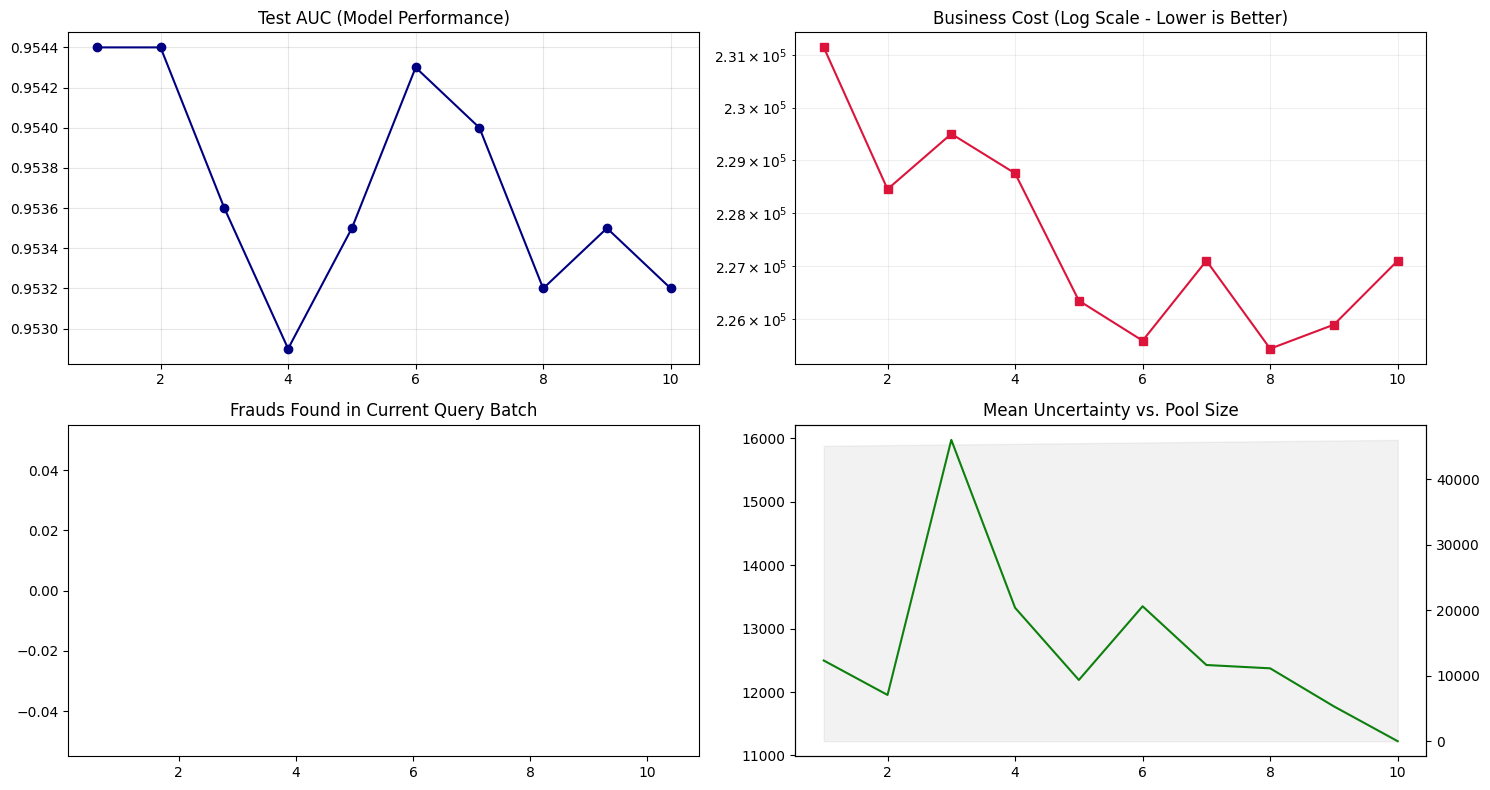

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- INITIALIZE LIVE PLOT ---
# Set up a multi-panel figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.ion() # Turn on interactive mode

# ── AL Query Log CSV ─────────────────────────────────────────
AL_QUERY_LOG_CSV = "al_queried_labels_expected_cost_reduction.csv"

# Wipe any previous run's file so we start fresh each full AL run
import os
if os.path.exists(AL_QUERY_LOG_CSV):
    os.remove(AL_QUERY_LOG_CSV)
    print(f"🗑️  Cleared previous '{AL_QUERY_LOG_CSV}'")

print(f"📝 AL queries will be appended to '{AL_QUERY_LOG_CSV}' each loop.")


al_log = []

print(f"\n{'═'*65}")
print(f"  Starting Active Learning — {N_AL_LOOPS} loops × {N_QUERY_PER_LOOP} queries")
print(f"{'═'*65}\n")
print(f'  Number of rows in df_remaining_unlabeled_pool = {len(df_remaining_unlabeled_pool)}')

for al_loop in tqdm(range(N_AL_LOOPS), desc="AL Loops", unit="loop"):
    # ── Slice this loop's non-overlapping subsample ───────────────────────
    chunk_start = al_loop * N_SUBSAMPLE
    chunk_end   = chunk_start + N_SUBSAMPLE
    df_chunk    = df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[chunk_start:chunk_end]   # view, not copy yet

    # ── STEP 1: Score the subsample ───────────────────────────────────────
    X_unlabeled     = df_chunk.drop(columns=[SUM_INSURED_COL])
    proba_unlabeled = current_model.predict(
        xgb.DMatrix(X_unlabeled),
        iteration_range=(0, current_model.best_iteration + 1)
    )    # returns probabilities directly (binary:logistic)
    si_pool_vals = df_chunk[SUM_INSURED_COL].values.astype(np.float64)

    # ── STEP 2: Select top-N most uncertain rows ──────────────────────────
    # -- cost_weighted: uncertainty scaled by insured amount --
    # uncertainty = 0.5 - np.abs(proba_unlabeled - 0.5)
    # norm_cost = si_pool_vals / (si_pool_vals.max() + 1)
    # scores = uncertainty * norm_cost
    # query_local_idx = np.argsort(-scores)[:N_QUERY_PER_LOOP]

    # -- uncertainty: closest to decision boundary --
    # uncertainty = np.abs(proba_unlabeled - 0.5)
    # query_local_idx = np.argsort(uncertainty)[:N_QUERY_PER_LOOP]
    # scores = 0.5 - uncertainty


    # -- diversity: k-means cluster + uncertainty (requires: ) --
    # from sklearn.preprocessing import StandardScaler
    # from sklearn.cluster import MiniBatchKMeans
    # X_scaled = StandardScaler().fit_transform(X_unlabeled)
    # kmeans = MiniBatchKMeans(n_clusters=min(N_QUERY_PER_LOOP, len(X_scaled)//2), random_state=42, batch_size=256).fit(X_scaled)
    # dists = np.min(kmeans.transform(X_scaled), axis=1)
    # scores = (1 - np.abs(2*proba_unlabeled - 1)) + 0.5*(dists/(dists.max()+1e-6))
    # query_local_idx = np.argsort(-scores)[:N_QUERY_PER_LOOP]

    # --Expected Cost Reduction
    # Calculates the financial risk the model is currently carrying for each row
    risk_if_0 = proba_unlabeled * (si_pool_vals * 0.9)  # Risk of False Negative (Missed Fraud)
    risk_if_1 = (1 - proba_unlabeled) * COST_FP         # Risk of False Positive (False Alarm)
    # Determine risk based on current model's decision at the optimal threshold
    scores = np.where(proba_unlabeled < THRESHOLD, risk_if_0, risk_if_1)
    # Query rows with the highest potential "regret" or current financial risk
    query_local_idx = np.argsort(-scores)[:N_QUERY_PER_LOOP]


    # ── End strategies ────────────────────────────────────────────────────

    # query_local_idx is relative to df_chunk; grab the actual rows
    query_df          = df_chunk.iloc[query_local_idx].copy()
    query_proba       = proba_unlabeled[query_local_idx]
    query_uncertainty = scores[query_local_idx]

    query_df["al_pred_proba"]  = query_proba
    query_df["al_uncertainty"] = query_uncertainty

    # # ── STEP 3: In-memory unlabeled_oracle label lookup──
    # Join query_df against unlabeled_oracle on all feature/meta columns (excludes al_pred_proba,
    # al_uncertainty, and TARGET_COL which doesn't exist in query_df yet)
    merge_cols = [c for c in unlabeled_oracle_join_cols if c in query_df.columns]

    newly_labeled = pd.merge(
            query_df,
            df_unlabeled_oracle[unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols,
            how="left"
        )

    # print(newly_labeled.columns)
    assert newly_labeled[TARGET_COL].notna().all(), \
        (f"Loop {al_loop+1}: {newly_labeled[TARGET_COL].isna().sum()} rows "
         f"failed oracle lookup — check that UNLABELED_CSV rows match the pool exactly.")

    # ── SAVE QUERIED LABELS TO CSV ────────────────────────────
    # newly_labeled has features + al_pred_proba + al_uncertainty + fraud_label (oracle)
    cols_to_save = df_labeled.columns.tolist() + ["al_pred_proba", "al_uncertainty"]
    save_df = newly_labeled[cols_to_save].copy()

    write_header = not os.path.exists(AL_QUERY_LOG_CSV)  # header only on first write
    save_df.to_csv(AL_QUERY_LOG_CSV, mode="a", header=write_header, index=False)
    # ─────────────────────────────────────────────────────────

    # ── STEP 4: Expand training pool ─────────────────────────────────────
    FEATURE_COLS = [c for c in df_labeled.columns if c not in [TARGET_COL, SUM_INSURED_COL]]
    X_new  = newly_labeled[FEATURE_COLS].values
    y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)
    si_new = newly_labeled[SUM_INSURED_COL].values.astype(np.float64)

    X_train_current  = pd.concat([X_train_current,
                                   pd.DataFrame(X_new, columns=FEATURE_COLS)],
                                   ignore_index=True)
    y_train_current  = np.concatenate([y_train_current, y_new])
    si_train_current = np.concatenate([si_train_current, si_new])


    # ── STEP 5: Retrain model on expanded pool ────────────────────────────
    current_model = build_and_train_model(
        xgb_params, N_ESTIMATORS, THRESHOLD, X_train_current, y_train_current, si_train_current
    )

    # ── STEP 6: Compute train-set stats for progress tracking ─────────────
    test_proba = current_model.predict(
        xgb.DMatrix(c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])),
        iteration_range=(0, current_model.best_iteration + 1)
    )
    test_cost = compute_business_cost(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba,
                                        c2_test_data[SUM_INSURED_COL].values.astype(np.float64), THRESHOLD)
    test_auc  = roc_auc_score(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba)

    loop_stats = {
        "loop"                : al_loop + 1,
        "train_pool_size"     : len(y_train_current),
        "unlabeled_remaining" : len(df_remaining_unlabeled_pool) - chunk_end,
        "fraud_in_query"      : int(y_new.sum()),
        "mean_uncertainty"    : round(float(query_uncertainty.mean()), 4),
        "test_auc"           : round(test_auc, 4),
        "test_business_cost" : round(test_cost, 2),
    }
    al_log.append(loop_stats)

    # ── STEP 7: LIVE PLOT UPDATE ────────────────────────────────────────
    df_temp = pd.DataFrame(al_log)
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 8))

    # Plot 1: AUC Progression
    axes[0, 0].plot(df_temp['loop'], df_temp['test_auc'], marker='o', color='navy')
    axes[0, 0].set_title('Test AUC (Model Performance)')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Business Cost
    axes[0, 1].plot(df_temp['loop'], df_temp['test_business_cost'], marker='s', color='crimson')
    axes[0, 1].set_yscale('log')  # <--- LOG SCALE APPLIED HERE
    axes[0, 1].set_title('Business Cost (Log Scale - Lower is Better)')
    axes[0, 1].grid(True, which="both", ls="-", alpha=0.2) # "both" shows minor gridlines for log scale

    # Plot 3: Fraud Detection Rate in Query
    axes[1, 0].bar(df_temp['loop'], df_temp['fraud_in_query'], color='orange', alpha=0.7)
    axes[1, 0].set_title('Frauds Found in Current Query Batch')

    # Plot 4: Uncertainty & Pool Size
    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(df_temp['loop'], df_temp['mean_uncertainty'], color='green', label='Uncertainty')
    ax2.fill_between(df_temp['loop'], df_temp['train_pool_size'], color='gray', alpha=0.1, label='Pool Size')
    axes[1, 1].set_title('Mean Uncertainty vs. Pool Size')

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Save final retrained XGBoost booster ─────────────────────
current_model.save_model(FINAL_MODEL_PATH)
print(f"✅ Final AL model saved → '{FINAL_MODEL_PATH}'")

# ── AL progression table ─────────────────────────────────────
df_log = pd.DataFrame(al_log)
print(f"\n{'─'*90}")
print(f"   Active Learning Progression Summary")
print(f"{'─'*90}")
print(df_log.to_string(index=False))
print(f"{'─'*90}")

# ── COMPREHENSIVE COMPARISON ─────────────────────────────────
al_auc  = df_log["test_auc"].iloc[-1]
al_cost = df_log["test_business_cost"].iloc[-1]
final_pool = df_log["train_pool_size"].iloc[-1]
total_frauds_found = df_log["fraud_in_query"].sum()

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL ACTIVE LEARNING MODEL")
print(f"{'═'*65}")

comparison_data = {
    "Metric": ["AUC", "Business Cost", "Fraud Found in AL"],
    "Baseline": [f"{baseline_auc:.4f}", f"${baseline_cost:,.2f}", "-"],
    "AL Final": [f"{al_auc:.4f}", f"${al_cost:,.2f}", f"{total_frauds_found}"],
    "Delta": [f"{al_auc - baseline_auc:+.4f}",
              f"${al_cost - baseline_cost:+,.2f}",
              "N/A"]
}

print(pd.DataFrame(comparison_data).to_string(index=False))
print(f"{'═'*65}")

improvement_pct = ((baseline_cost - al_cost) / baseline_cost) * 100
print(f"💡 Summary: AL reduced business cost by {improvement_pct:.2f}%")
print(f"   The model was enriched with {total_frauds_found} high-value fraud cases.")

✅ Final AL model saved → 'al_final_model_expected_cost_reduction.json'

──────────────────────────────────────────────────────────────────────────────────────────
   Active Learning Progression Summary
──────────────────────────────────────────────────────────────────────────────────────────
 loop  train_pool_size  unlabeled_remaining  fraud_in_query  mean_uncertainty  test_auc  test_business_cost
    1            45100                18000               0        12497.1283    0.9544            231150.0
    2            45200                16000               0        11954.1163    0.9544            228450.0
    3            45300                14000               0        15974.5543    0.9536            229500.0
    4            45400                12000               0        13328.3489    0.9529            228750.0
    5            45500                10000               0        12190.3850    0.9535            226350.0
    6            45600                 8000               0

## Non sequential branch

In [ ]:
# Randomly sample 1,000 points
df_sampled = df_remaining_unlabeled.sample(n=1000, random_state=60)

# Verify the shape
print(f"New shape: {df_sampled.shape}")
# ── Working copies (mutated each loop) ───────────────────────

# ── Load tuned hyper-parameters ──────────────────────────────
xgb_params, N_ESTIMATORS, THRESHOLD = load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  Threshold : {THRESHOLD}")
print(f"  XGB params:")
for k, v in xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Working copies (mutated each loop) ───────────────────────
current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_pool = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])            # grows as new labels arrive
y_pool = c1_train_data[TARGET_COL].values.astype(np.int32)
si_pool = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)


# ── Train baseline model on full labeled pool ─────────────────
print("\n[BASELINE] Training baseline XGBoost on labeled pool …")
baseline_model = build_and_train_model(xgb_params, N_ESTIMATORS, THRESHOLD, X_pool, y_pool, si_pool)

current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_train_current = X_pool.copy()            # grows as new labels arrive
y_train_current = y_pool.copy()
si_train_current = si_pool.copy()
df_sampled_pool = df_sampled.copy()    # shrinks as rows are queried

New shape: (1000, 44)
[BASELINE] Loaded params from 'best_params.json'
  Threshold : 0.10854643368675157
  XGB params:
    max_depth                 = 5
    min_child_weight          = 4
    gamma                     = 0.45606998421703593
    learning_rate             = 0.12448918446337819
    subsample                 = 0.5998368910791798
    colsample_bytree          = 0.708540663048167
    colsample_bylevel         = 0.7554487413172255
    reg_alpha                 = 2.4298880728901692e-08
    reg_lambda                = 0.0019275890163896973

[BASELINE] Training baseline XGBoost on labeled pool …


In [ ]:
# ── Expand training pool ─────────────────────────
X_new  = df_sampled_pool.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_new  = df_sampled_pool[TARGET_COL].values.astype(np.int32)
si_new = df_sampled_pool[SUM_INSURED_COL].values.astype(np.float64)

X_train_current  = pd.concat([X_train_current, X_new],
                                ignore_index=True)
y_train_current  = np.concatenate([y_train_current, y_new])
si_train_current = np.concatenate([si_train_current, si_new])

# ── Retrain model on expanded pool ───────────────
current_model = build_and_train_model(
    xgb_params, N_ESTIMATORS, THRESHOLD, X_train_current, y_train_current, si_train_current
)

test_proba = current_model.predict(
    xgb.DMatrix(c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])),
    iteration_range=(0, current_model.best_iteration + 1)
)
test_cost = compute_business_cost(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba,
                                    c2_test_data[SUM_INSURED_COL].values.astype(np.float64), THRESHOLD)
test_auc  = roc_auc_score(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba)

nsl_log = []
loop_stats = {
    "train_pool_size"   : len(y_train_current),
    "fraud_in_query"    : int(y_new.sum()),
    "test_auc"         : round(test_auc, 4),
    "test_business_cost": round(test_cost, 2),
}
nsl_log.append(loop_stats)
print(  f"train_pool={loop_stats['train_pool_size']:,}  "
        f"fraud_in_query={loop_stats['fraud_in_query']}  "
        f"AUC={loop_stats['test_auc']:.4f}  "
        f"biz_cost={loop_stats['test_business_cost']:,.0f}  ")

train_pool=46,000  fraud_in_query=27  AUC=0.9542  biz_cost=231,750  


In [ ]:
# ── Save final retrained XGBoost booster ─────────────────────
current_model.save_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
print(f"✅ Final NSL model saved → '{FINAL_NON_SEQUENTIAL_MODEL_PATH}'")

# ── NSL progression table ─────────────────────────────────────
df_log = pd.DataFrame(nsl_log)
print(f"\n{'─'*90}")
print(f"  Non-Sequential Learning Progression Summary")
print(f"{'─'*90}")
print(df_log.to_string(index=False))
print(f"{'─'*90}")

# ── Delta vs baseline ─────────────────────────────────────────
nsl_auc  = df_log["test_auc"].iloc[-1]
nsl_cost = df_log["test_business_cost"].iloc[-1]

print(f"\n  Baseline → Final NSL model (train-set, indicative only)")
print(f"  AUC          : {nsl_auc:.4f}  ")
print(f"  AUC          : {baseline_auc:.4f}  →  {nsl_auc:.4f}  "
      f"(Δ {nsl_auc - baseline_auc:+.4f})")
print(f"  Business cost: {baseline_cost:,.0f}  →  {nsl_cost:,.0f}  "
      f"(Δ {nsl_cost - baseline_cost:+,.0f})")

print(f"\n💡 Next step: evaluate '{FINAL_NON_SEQUENTIAL_MODEL_PATH}' on a held-out labeled test set.")
print(f"   Load with: booster = xgb.Booster(); "
      f"booster.load_model('{FINAL_NON_SEQUENTIAL_MODEL_PATH}')")

✅ Final NSL model saved → 'nonsequential_final_model.json'

──────────────────────────────────────────────────────────────────────────────────────────
  Non-Sequential Learning Progression Summary
──────────────────────────────────────────────────────────────────────────────────────────
 train_pool_size  fraud_in_query  test_auc  test_business_cost
           46000              27    0.9542            231750.0
──────────────────────────────────────────────────────────────────────────────────────────

  Baseline → Final NSL model (train-set, indicative only)
  AUC          : 0.9542  
  AUC          : 0.9533  →  0.9542  (Δ +0.0009)
  Business cost: 232,950  →  231,750  (Δ -1,200)

💡 Next step: evaluate 'nonsequential_final_model.json' on a held-out labeled test set.
   Load with: booster = xgb.Booster(); booster.load_model('nonsequential_final_model.json')


## Comparison of AL and Non-sequential

### **case2 (test)**

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — AL model vs Non-Sequential model
#  on held-out df_final_test (never seen during training or AL)
# ══════════════════════════════════════════════════════════════════

X_test_final  = c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = c2_test_data[TARGET_COL].values.astype(np.int32)
si_test_final = c2_test_data[SUM_INSURED_COL].values.astype(np.float64)

dtest_final   = xgb.DMatrix(X_test_final)

print(f"[FINAL TEST SET] {len(c2_test_data):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Helper: compute all metrics for one booster ───────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision   = tp / max(tp + fp, 1)
    recall      = tp / max(tp + fn, 1)
    f1          = 2 * precision * recall / max(precision + recall, 1e-9)
    auc         = roc_auc_score(y_true, y_proba)
    biz_cost    = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / len(y_true)

    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")
    print(f"  Threshold       : {threshold:.4f}")
    print(f"  AUC-ROC         : {auc:.4f}")
    print(f"  Business cost   : {biz_cost:,.2f}   (per row: {cost_per_row:,.4f})")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision       : {precision:.4f}")
    print(f"  Recall          : {recall:.4f}")
    print(f"  F1              : {f1:.4f}")
    print(f"{'═'*60}")

    return {
        "model"         : label,
        "auc"           : round(auc, 4),
        "biz_cost"      : round(biz_cost, 2),
        "cost_per_row"  : round(cost_per_row, 4),
        "tp"            : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"     : round(precision, 4),
        "recall"        : round(recall, 4),
        "f1"            : round(f1, 4),
    }


# ── Load both models ──────────────────────────────────────────────
booster_al        = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)
booster_ns        = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_baseline  = xgb.Booster(); booster_baseline.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)


# ── Evaluate ──────────────────────────────────────────────────────
stats_al = evaluate_model(booster_al, dtest_final, y_test_final, si_test_final,
                           THRESHOLD, label="AL Model (sequential, final)")
stats_ns = evaluate_model(booster_ns, dtest_final, y_test_final, si_test_final,
                           THRESHOLD, label="Non-Sequential Model (random 1k batch)")


# ── Side-by-side comparison table ────────────────────────────────
df_compare = pd.DataFrame([stats_al, stats_ns]).set_index("model").T
print(f"\n{'─'*70}")
print(f"  Head-to-head comparison on final test set ({len(y_test_final):,} rows)")
print(f"{'─'*70}")
print(df_compare.to_string())
print(f"{'─'*70}")

# ── Delta: AL vs Non-Sequential ───────────────────────────────────
delta_auc  = stats_al["auc"]      - stats_ns["auc"]
delta_cost = stats_al["biz_cost"] - stats_ns["biz_cost"]
delta_rec  = stats_al["recall"]   - stats_ns["recall"]
delta_f1   = stats_al["f1"]       - stats_ns["f1"]

print(f"\n  Δ AL − Non-Sequential (positive = AL better for AUC/recall/f1, lower for cost)")
print(f"  AUC          : {delta_auc:+.4f}")
print(f"  Business cost: {delta_cost:+,.2f}   {'✅ AL cheaper' if delta_cost < 0 else '❌ AL more expensive'}")
print(f"  Recall       : {delta_rec:+.4f} ")
print(f"  F1           : {delta_f1:+.4f}")

[FINAL TEST SET] 10,000 rows | fraud=300 (3.00%)

════════════════════════════════════════════════════════════
  AL Model (sequential, final)
════════════════════════════════════════════════════════════
  Threshold       : 0.1085
  AUC-ROC         : 0.9536
  Business cost   : 228,300.00   (per row: 22.8300)
  TP / FP / TN / FN : 300 / 1322 / 8378 / 0
  Precision       : 0.1850
  Recall          : 1.0000
  F1              : 0.3122
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Non-Sequential Model (random 1k batch)
════════════════════════════════════════════════════════════
  Threshold       : 0.1085
  AUC-ROC         : 0.9542
  Business cost   : 231,750.00   (per row: 23.1750)
  TP / FP / TN / FN : 300 / 1345 / 8355 / 0
  Precision       : 0.1824
  Recall          : 1.0000
  F1              : 0.3085
════════════════════════════════════════════════════════════

────────────────────────────────────────────────

### Out-of-sample (OOS) test

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — Non-Sequential vs AL
# ══════════════════════════════════════════════════════════════════

# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

df_sampled               = df_remaining_unlabeled.sample(n=1000, random_state=60)
df_unlabeled_al_samples  = pd.read_csv('/content/al_queried_labels.csv')
df_unlabeled             = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen (training pool, AL queries, random sample)
seen = pd.concat([
    df_sampled[df_unlabeled.columns],
    df_unlabeled_al_samples[df_unlabeled.columns],
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    print(f"\n{'═'*62}")
    print(f"  {label}")
    print(f"{'═'*62}")
    print(f"  Threshold         : {threshold:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  Business cost     : {biz_cost:>15,.2f}")
    print(f"  Cost per row      : {cost_per_row:>15,.4f}")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"{'═'*62}")

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load both models ──────────────────────────────────────────────────
booster_ns = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_al = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)


# ── Step 5: Evaluate both ────────────────────────────────────────────────────
stats_ns = evaluate_model(
    booster_ns, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Non-Sequential (random 1k unlabeled)"
)
stats_al = evaluate_model(
    booster_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Active Learning (sequential, 10 loops)"
)


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_ns, stats_al])
    .set_index("model")
    .T
)

print(f"\n{'─'*80}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*80}")
print(df_compare.to_string())
print(f"{'─'*80}")


# ── Step 7: Delta — AL vs Non-Sequential ─────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")

delta_row(stats_al, stats_ns, "AL", "Non-Sequential")

df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 1,948
final held-out test rows     : 28,072
(gap = internal dupes in df_unlabeled: -20)

[FINAL TEST SET] 28,072 rows | fraud=843 (3.00%)

══════════════════════════════════════════════════════════════
  Non-Sequential (random 1k unlabeled)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9567
  Business cost     :      620,400.00
  Cost per row      :         22.1003
  TP / FP / TN / FN : 843 / 3574 / 23655 / 0
  Precision         : 0.1909
  Recall            : 1.0000
  F1                : 0.3205
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Active Learning (sequential, 10 loops)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9554
  Business cost     :      609,900.00
  Cost per row      :         21.7

### Comparison of AL and Non-sequential with Baseline

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — Baseline vs Non-Sequential vs AL
# ══════════════════════════════════════════════════════════════════

# ── Step 0: Save the baseline model (add this right after baseline_model is trained above) ──
# If you still have `baseline_model` in memory, just save it now:
BASELINE_MODEL_PATH = "baseline_model.json"
baseline_model.save_model(BASELINE_MODEL_PATH)
print(f"✅ Baseline model saved → '{BASELINE_MODEL_PATH}'")


# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

df_sampled               = df_remaining_unlabeled.sample(n=1000, random_state=60)
df_unlabeled_al_samples  = pd.read_csv('/content/al_queried_labels.csv')
df_unlabeled             = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen (training pool, AL queries, random sample, c2_test_data)
seen = pd.concat([
    df_sampled[df_unlabeled.columns],
    df_unlabeled_al_samples[df_unlabeled.columns],
    # c2_test_data[df_unlabeled.columns],
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

# Note: df_unlabeled may have duplicate rows internally, so
# len(seen) + len(df_final_test) can differ from len(df_unlabeled)
print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    print(f"\n{'═'*62}")
    print(f"  {label}")
    print(f"{'═'*62}")
    print(f"  Threshold         : {threshold:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  Business cost     : {biz_cost:>15,.2f}")
    print(f"  Cost per row      : {cost_per_row:>15,.4f}")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"{'═'*62}")

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load all three models ────────────────────────────────────────────
booster_baseline = xgb.Booster(); booster_baseline.load_model(BASELINE_MODEL_PATH)
booster_ns       = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_al       = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)


# ── Step 5: Evaluate all three ───────────────────────────────────────────────
stats_baseline = evaluate_model(
    booster_baseline, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Baseline (labeled pool only)"
)
stats_ns = evaluate_model(
    booster_ns, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Non-Sequential (random 1k unlabeled)"
)
stats_al = evaluate_model(
    booster_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Active Learning (sequential, 10 loops)"
)


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_baseline, stats_ns, stats_al])
    .set_index("model")
    .T
)

print(f"\n{'─'*80}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*80}")
print(df_compare.to_string())
print(f"{'─'*80}")


# ── Step 7: Deltas vs Baseline ───────────────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")

delta_row(stats_ns, stats_baseline, "Non-Sequential", "Baseline")
delta_row(stats_al, stats_baseline, "AL",             "Baseline")
delta_row(stats_al, stats_ns,       "AL",             "Non-Sequential")

✅ Baseline model saved → 'baseline_model.json'
df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 1,948
final held-out test rows     : 28,072
(gap = internal dupes in df_unlabeled: -20)

[FINAL TEST SET] 28,072 rows | fraud=843 (3.00%)

══════════════════════════════════════════════════════════════
  Baseline (labeled pool only)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9559
  Business cost     :      618,750.00
  Cost per row      :         22.0415
  TP / FP / TN / FN : 843 / 3563 / 23666 / 0
  Precision         : 0.1913
  Recall            : 1.0000
  F1                : 0.3212
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Non-Sequential (random 1k unlabeled)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9567
  Business cost     :      620,400.

## Accuracy based AL

The accuracy-based branch keeps `sum_insured` as a feature, trains the model to maximize ROC-AUC, and uses uncertainty / entropy / diversity style query scoring.

In [ ]:

import os
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import clear_output
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings("ignore")

# ╔══════════════════════════════════════════════════════════╗
# ║                ACCURACY AL CONFIGURATION                ║
# ╚══════════════════════════════════════════════════════════╝
N_CANDIDATES_PER_STRAT = 200
N_MAX_INTERSECT        = 100
ACC_FINAL_MODEL_PATH   = "accuracy_al_final_model.json"
ACC_AL_QUERY_LOG_CSV   = "accuracy_al_queried_labels.csv"

# ── Helpers ────────────────────────────────────────────────
def acc_load_params_from_json(json_path):
    xgb_params, n_estimators, _ = load_params_from_json(json_path)
    return xgb_params, n_estimators

def acc_build_and_train_model(params, n_estimators, X_train, y_train):
    pos = max(int((y_train == 1).sum()), 1)
    neg = int((y_train == 0).sum())
    scale_pos_weight = neg / pos

    dtrain = xgb.DMatrix(X_train, label=y_train)
    train_params = {
        "objective"        : "binary:logistic",
        "tree_method"      : "hist",
        "seed"             : 42,
        "verbosity"        : 0,
        "scale_pos_weight" : scale_pos_weight,
        "eval_metric"      : "auc",
        **params,
    }

    booster = xgb.train(
        train_params,
        dtrain,
        num_boost_round       = n_estimators,
        evals                 = [(dtrain, "train")],
        early_stopping_rounds  = EARLY_STOPPING,
        maximize              = True,
        verbose_eval          = False,
    )
    return booster

def acc_predict_proba(model, X):
    dmat = xgb.DMatrix(X)
    best_iter = getattr(model, "best_iteration", None)
    if best_iter is None:
        return model.predict(dmat)
    return model.predict(dmat, iteration_range=(0, best_iter + 1))

def acc_evaluate_model(model, X_test, y_test, label):
    y_proba = acc_predict_proba(model, X_test)
    y_pred  = (y_proba >= 0.5).astype(int)
    stats = {
        "auc"      : roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall"   : recall_score(y_test, y_pred, zero_division=0),
        "f1"       : f1_score(y_test, y_pred, zero_division=0),
    }
    print(
        f"  {label:<22} "
        f"AUC={stats['auc']:.4f} | "
        f"Precision={stats['precision']:.4f} | "
        f"Recall={stats['recall']:.4f} | "
        f"F1={stats['f1']:.4f}"
    )
    return stats, y_proba

# ── Load tuned hyper-parameters ────────────────────────────
acc_xgb_params, acc_n_estimators = acc_load_params_from_json(BEST_PARAMS_JSON)

print(f"[BASELINE] Loaded params from '{BEST_PARAMS_JSON}'")
print(f"  XGB params:")
for k, v in acc_xgb_params.items():
    print(f"    {k:<25} = {v}")

# ── Load labeled training pool ─────────────────────────────
acc_feature_cols = [c for c in df_labeled.columns if c != TARGET_COL]
acc_X_pool_train = c1_train_data.drop(columns=[TARGET_COL])
acc_y_pool_train = c1_train_data[TARGET_COL].values.astype(np.int32)

acc_X_pool_test  = c1_test_data.drop(columns=[TARGET_COL])
acc_y_pool_test  = c1_test_data[TARGET_COL].values.astype(np.int32)

print(f"fraud={acc_y_pool_train.sum():,} ({100*acc_y_pool_train.mean():.1f}%)")

# ── Train baseline model on full labeled pool ──────────────
print("\n[BASELINE] Training accuracy-driven XGBoost on labeled pool …")
acc_baseline_model = acc_build_and_train_model(
    acc_xgb_params, acc_n_estimators, acc_X_pool_train, acc_y_pool_train
)

acc_baseline_stats, acc_baseline_proba = acc_evaluate_model(
    acc_baseline_model, acc_X_pool_test, acc_y_pool_test, "Baseline"
)

print(f"  ✅ Baseline trained.")
print(f"  Baseline ROC-AUC (test)      : {acc_baseline_stats['auc']:.4f}")
print(f"  Baseline F1 (test)           : {acc_baseline_stats['f1']:.4f}")
print(f"  (Held-out scores are used only as AL progress reference)")
print(f"  Number of rows in LABELED_CSV = {len(df_labeled)}")

# ── Unlabeled pool for AL ──────────────────────────────────
acc_df_unlabeled_oracle = df_unlabeled
assert TARGET_COL in acc_df_unlabeled_oracle.columns, (
    f"'{TARGET_COL}' not found in oracle — cannot look up labels."
)
acc_unlabeled_oracle_join_cols = [
    c for c in df_remaining_unlabeled.columns if c != TARGET_COL
]

assert N_SUBSAMPLE >= N_QUERY_PER_LOOP, (
    f"N_SUBSAMPLE ({N_SUBSAMPLE}) must be ≥ N_QUERY_PER_LOOP ({N_QUERY_PER_LOOP})"
)
assert N_SUBSAMPLE * N_AL_LOOPS <= len(df_remaining_unlabeled), (
    f"Not enough unlabeled rows: need {N_SUBSAMPLE*N_AL_LOOPS:,} "
    f"({N_AL_LOOPS} loops × {N_SUBSAMPLE}) but pool has {len(df_remaining_unlabeled):,}"
)

rng = np.random.default_rng(seed=42)
acc_shuffled_order = rng.permutation(len(df_remaining_unlabeled))
acc_df_remaining_unlabeled_pool = (
    df_remaining_unlabeled.copy()
    .iloc[acc_shuffled_order]
    .reset_index(drop=True)
)

print(f"  Number of rows in df_remaining_unlabeled_pool = {len(acc_df_remaining_unlabeled_pool)}")

# ── Working copies (mutated each loop) ──────────────────────
acc_current_model   = acc_baseline_model
acc_X_train_current = acc_X_pool_train.copy()
acc_y_train_current = acc_y_pool_train.copy()

# ── Query log ───────────────────────────────────────────────
if os.path.exists(ACC_AL_QUERY_LOG_CSV):
    os.remove(ACC_AL_QUERY_LOG_CSV)
    print(f"🗑️  Cleared previous '{ACC_AL_QUERY_LOG_CSV}'")

print(f"📝 AL queries will be appended to '{ACC_AL_QUERY_LOG_CSV}' each loop.")

acc_log = []

print(f"\n{'═'*65}")
print(f"  Starting Accuracy Active Learning — {N_AL_LOOPS} loops × {N_QUERY_PER_LOOP} queries")
print(f"{'═'*65}\n")

for al_loop in tqdm(range(N_AL_LOOPS), desc="AL Loops", unit="loop"):
    chunk_start = al_loop * N_SUBSAMPLE
    chunk_end   = chunk_start + N_SUBSAMPLE
    acc_df_chunk = acc_df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[chunk_start:chunk_end].copy()

    # ── STEP 1: Score the subsample ─────────────────────────
    X_unlabeled     = acc_df_chunk
    proba_unlabeled = acc_predict_proba(acc_current_model, X_unlabeled)

    # ── STEP 2: Query strategy scores ───────────────────────
    score_unc = 0.5 - np.abs(proba_unlabeled - 0.5)

    eps = 1e-12
    p_clip = np.clip(proba_unlabeled, eps, 1 - eps)
    score_entropy = -(
        p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip)
    ) / np.log(2)

    X_scaled = StandardScaler().fit_transform(X_unlabeled)
    n_clusters = min(N_CANDIDATES_PER_STRAT, max(2, len(X_scaled) // 2))
    n_clusters = min(n_clusters, len(X_scaled))
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=256,
        n_init="auto"
    ).fit(X_scaled)
    dists = np.min(kmeans.transform(X_scaled), axis=1)
    dist_norm = dists / (dists.max() + 1e-6)
    score_div = score_unc + 0.5 * dist_norm

    score_combo = 0.5 * score_unc + 0.5 * score_entropy

    idx_unc = set(np.argsort(-score_unc)[:N_CANDIDATES_PER_STRAT])
    idx_entropy = set(np.argsort(-score_entropy)[:N_CANDIDATES_PER_STRAT])
    idx_div = set(np.argsort(-score_div)[:N_CANDIDATES_PER_STRAT])
    idx_combo = set(np.argsort(-score_combo)[:N_CANDIDATES_PER_STRAT])

    # ── STEP 3: Intersection Logic ──────────────────────────
    intersected_set = idx_unc & idx_entropy & idx_div & idx_combo
    common_idx_all = list(intersected_set)
    num_common_found = len(common_idx_all)

    if num_common_found > 0:
        common_idx_all_sorted = sorted(common_idx_all, key=lambda i: score_combo[i], reverse=True)
        query_local_idx = common_idx_all_sorted[:N_MAX_INTERSECT]

        query_df          = acc_df_chunk.iloc[query_local_idx].copy()
        query_proba       = proba_unlabeled[query_local_idx]
        query_uncertainty = score_unc[query_local_idx]

        query_df["al_pred_proba"]  = query_proba
        query_df["al_uncertainty"] = query_uncertainty

        merge_cols = [c for c in acc_unlabeled_oracle_join_cols if c in query_df.columns]
        newly_labeled = pd.merge(
            query_df,
            acc_df_unlabeled_oracle[acc_unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols,
            how="left"
        )

        assert newly_labeled[TARGET_COL].notna().all(), (
            f"Loop {al_loop+1}: {newly_labeled[TARGET_COL].isna().sum()} rows "
            f"failed oracle lookup — check that UNLABELED_CSV rows match the pool exactly."
        )

        cols_to_save = df_labeled.columns.tolist() + ["al_pred_proba", "al_uncertainty"]
        save_df = newly_labeled[cols_to_save].copy()
        write_header = not os.path.exists(ACC_AL_QUERY_LOG_CSV)
        save_df.to_csv(ACC_AL_QUERY_LOG_CSV, mode="a", header=write_header, index=False)

        X_new = newly_labeled[acc_feature_cols]
        y_new = newly_labeled[TARGET_COL].values.astype(np.int32)

        acc_X_train_current = pd.concat(
            [acc_X_train_current, X_new],
            ignore_index=True
        )
        acc_y_train_current = np.concatenate([acc_y_train_current, y_new])

        acc_current_model = acc_build_and_train_model(
            acc_xgb_params,
            acc_n_estimators,
            acc_X_train_current,
            acc_y_train_current
        )

        loop_fraud_found = int(y_new.sum())
        loop_mean_unc    = round(float(query_uncertainty.mean()), 4)
    else:
        loop_fraud_found = 0
        loop_mean_unc    = 0.0

    # ── STEP 4: Compute test-set stats for progress tracking ─
    test_stats, _ = acc_evaluate_model(
        acc_current_model, acc_X_pool_test, acc_y_pool_test, f"Loop {al_loop+1}"
    )

    loop_stats = {
        "loop"               : al_loop + 1,
        "train_pool_size"    : len(acc_y_train_current),
        "unlabeled_remaining": len(acc_df_remaining_unlabeled_pool) - chunk_end,
        "common_queries"     : min(num_common_found, N_MAX_INTERSECT),
        "fraud_in_query"     : loop_fraud_found,
        "mean_uncertainty"   : loop_mean_unc,
        "test_auc"           : round(test_stats["auc"], 4),
        "test_f1"            : round(test_stats["f1"], 4),
    }
    acc_log.append(loop_stats)

    # ── STEP 5: LIVE PLOT UPDATE ─────────────────────────────
    df_temp = pd.DataFrame(acc_log)
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 14))

    axes[0, 0].plot(df_temp["loop"], df_temp["test_auc"], marker="o")
    axes[0, 0].set_title("Test ROC-AUC (Model Performance)")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(df_temp["loop"], df_temp["test_f1"], marker="s")
    axes[0, 1].set_title("Test F1-Score")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].bar(df_temp["loop"], df_temp["common_queries"], alpha=0.7)
    axes[1, 0].set_title(f"Common Queries Found in Intersection (Max {N_MAX_INTERSECT})")

    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(df_temp["loop"], df_temp["mean_uncertainty"], color="green", label="Uncertainty")
    ax2.fill_between(df_temp["loop"], df_temp["train_pool_size"], color="gray", alpha=0.1, label="Pool Size")
    axes[1, 1].set_title("Mean Uncertainty vs. Pool Size")

    plt.tight_layout()
    plt.show()

# ── Save final retrained model ──────────────────────────────
acc_current_model.save_model(ACC_FINAL_MODEL_PATH)
print(f"✅ Final Accuracy AL model saved → '{ACC_FINAL_MODEL_PATH}'")

# ── Progress table ──────────────────────────────────────────
acc_df_log = pd.DataFrame(acc_log)
print(f"\n{'─'*100}")
print(f"   Accuracy Active Learning Progression Summary")
print(f"{'─'*100}")
print(acc_df_log.to_string(index=False))
print(f"{'─'*100}")

# ── Baseline vs final comparison ────────────────────────────
acc_al_stats, acc_al_proba = acc_evaluate_model(
    acc_current_model, acc_X_pool_test, acc_y_pool_test, "Final Accuracy AL"
)

comparison_data = {
    "Metric": ["ROC-AUC", "Precision", "Recall", "F1-Score", "Frauds Found in AL"],
    "Baseline": [
        f"{acc_baseline_stats['auc']:.4f}",
        f"{acc_baseline_stats['precision']:.4f}",
        f"{acc_baseline_stats['recall']:.4f}",
        f"{acc_baseline_stats['f1']:.4f}",
        "-",
    ],
    "Accuracy AL Final": [
        f"{acc_al_stats['auc']:.4f}",
        f"{acc_al_stats['precision']:.4f}",
        f"{acc_al_stats['recall']:.4f}",
        f"{acc_al_stats['f1']:.4f}",
        f"{acc_df_log['fraud_in_query'].sum()}",
    ],
    "Delta": [
        f"{acc_al_stats['auc'] - acc_baseline_stats['auc']:+.4f}",
        f"{acc_al_stats['precision'] - acc_baseline_stats['precision']:+.4f}",
        f"{acc_al_stats['recall'] - acc_baseline_stats['recall']:+.4f}",
        f"{acc_al_stats['f1'] - acc_baseline_stats['f1']:+.4f}",
        "N/A",
    ],
}

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL ACCURACY-BASED ACTIVE LEARNING MODEL")
print(f"{'═'*65}")
print(pd.DataFrame(comparison_data).to_string(index=False))
print(f"{'═'*65}")


## Non sequential branch (Accuracy based)

In [ ]:

# ── Non Sequential Accuracy branch ─────────────────────────
ACC_FINAL_NON_SEQUENTIAL_MODEL_PATH = "accuracy_nonsequential_final_model.json"
ACC_NSL_QUERY_LOG_CSV = "accuracy_nonsequential_queried_labels.csv"

# Randomly sample 1,000 points
acc_df_sampled = df_remaining_unlabeled.sample(n=1000, random_state=60)
print(f"New shape: {acc_df_sampled.shape}")

# Expand training pool
acc_X_new = acc_df_sampled.drop(columns=[TARGET_COL])
acc_y_new = acc_df_sampled[TARGET_COL].values.astype(np.int32)

acc_X_train_current = pd.concat([acc_X_pool_train, acc_X_new], ignore_index=True)
acc_y_train_current = np.concatenate([acc_y_pool_train, acc_y_new])

# Retrain model on expanded pool
acc_nsl_model = acc_build_and_train_model(
    acc_xgb_params,
    acc_n_estimators,
    acc_X_train_current,
    acc_y_train_current
)

# Evaluate on held-out test data
acc_nsl_stats, _ = acc_evaluate_model(
    acc_nsl_model, acc_X_pool_test, acc_y_pool_test, "Final Accuracy NSL"
)

# Save model and sampled rows for traceability
acc_nsl_model.save_model(ACC_FINAL_NON_SEQUENTIAL_MODEL_PATH)
print(f"✅ Final Accuracy NSL model saved → '{ACC_FINAL_NON_SEQUENTIAL_MODEL_PATH}'")

acc_sample_proba = acc_predict_proba(acc_nsl_model, acc_X_new)
save_nsl_df = acc_df_sampled.copy()
save_nsl_df["al_pred_proba"] = acc_sample_proba
save_nsl_df["al_uncertainty"] = 0.5 - np.abs(save_nsl_df["al_pred_proba"] - 0.5)
save_nsl_df.to_csv(ACC_NSL_QUERY_LOG_CSV, index=False)

acc_nsl_log = [{
    "train_pool_size"     : len(acc_y_train_current),
    "fraud_in_query"      : int(acc_y_new.sum()),
    "test_auc"            : round(acc_nsl_stats["auc"], 4),
    "test_precision"      : round(acc_nsl_stats["precision"], 4),
    "test_recall"         : round(acc_nsl_stats["recall"], 4),
    "test_f1"             : round(acc_nsl_stats["f1"], 4),
}]
acc_nsl_df_log = pd.DataFrame(acc_nsl_log)

print(f"\n{'─'*90}")
print(f"  Non-Sequential Accuracy Learning Summary")
print(f"{'─'*90}")
print(acc_nsl_df_log.to_string(index=False))
print(f"{'─'*90}")

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL NON-SEQUENTIAL ACCURACY MODEL")
print(f"{'═'*65}")

nsl_comparison_data = {
    "Metric": ["ROC-AUC", "Precision", "Recall", "F1-Score", "Frauds Found in Sample"],
    "Baseline": [
        f"{acc_baseline_stats['auc']:.4f}",
        f"{acc_baseline_stats['precision']:.4f}",
        f"{acc_baseline_stats['recall']:.4f}",
        f"{acc_baseline_stats['f1']:.4f}",
        "-",
    ],
    "Accuracy NSL Final": [
        f"{acc_nsl_stats['auc']:.4f}",
        f"{acc_nsl_stats['precision']:.4f}",
        f"{acc_nsl_stats['recall']:.4f}",
        f"{acc_nsl_stats['f1']:.4f}",
        f"{int(acc_y_new.sum())}",
    ],
    "Delta": [
        f"{acc_nsl_stats['auc'] - acc_baseline_stats['auc']:+.4f}",
        f"{acc_nsl_stats['precision'] - acc_baseline_stats['precision']:+.4f}",
        f"{acc_nsl_stats['recall'] - acc_baseline_stats['recall']:+.4f}",
        f"{acc_nsl_stats['f1'] - acc_baseline_stats['f1']:+.4f}",
        "N/A",
    ],
}

print(pd.DataFrame(nsl_comparison_data).to_string(index=False))
print(f"{'═'*65}")


# Hybrid Accuracy based AL

In [ ]:

# ╔══════════════════════════════════════════════════════════╗
# ║                 HYBRID ACCURACY AL CONFIG               ║
# ╚══════════════════════════════════════════════════════════╝
N_CANDIDATES_PER_STRAT = 200
N_MAX_INTERSECT        = 100
ACC_FINAL_HYBRID_AL_MODEL_PATH = "accuracy_hybrid_al_final_model.json"
ACC_HYBRID_AL_QUERY_LOG_CSV     = "accuracy_hybrid_al_queried_labels.csv"

# ── Working copies (mutated each loop) ───────────────────────
acc_current_model   = acc_baseline_model
acc_X_train_current = acc_X_pool_train.copy()
acc_y_train_current = acc_y_pool_train.copy()

# --- INITIALIZE LIVE PLOT ---
plt.ion()

if os.path.exists(ACC_HYBRID_AL_QUERY_LOG_CSV):
    os.remove(ACC_HYBRID_AL_QUERY_LOG_CSV)
    print(f"🗑️  Cleared previous '{ACC_HYBRID_AL_QUERY_LOG_CSV}'")

print(f"📝 AL queries will be appended to '{ACC_HYBRID_AL_QUERY_LOG_CSV}' each loop.")

acc_hybrid_log = []

print(f"\n{'═'*65}")
print(f"  Starting Hybrid Accuracy Active Learning — {N_AL_LOOPS} loops")
print(f"  Candidates per strat: {N_CANDIDATES_PER_STRAT} | Max Oracle Queries: {N_MAX_INTERSECT}")
print(f"{'═'*65}\n")
print(f'  Number of rows in df_remaining_unlabeled_pool = {len(acc_df_remaining_unlabeled_pool)}')

for al_loop in tqdm(range(N_AL_LOOPS), desc="AL Loops", unit="loop"):
    chunk_start = al_loop * N_SUBSAMPLE
    chunk_end   = chunk_start + N_SUBSAMPLE
    acc_df_chunk = acc_df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[chunk_start:chunk_end].copy()

    # ── STEP 1: Score the subsample ─────────────────────────
    X_unlabeled     = acc_df_chunk
    proba_unlabeled = acc_predict_proba(acc_current_model, X_unlabeled)

    # ── STEP 2: Calculate scores for all 4 strategies ───────
    score_unc = 0.5 - np.abs(proba_unlabeled - 0.5)

    eps = 1e-12
    p_clip = np.clip(proba_unlabeled, eps, 1 - eps)
    score_entropy = -(
        p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip)
    ) / np.log(2)

    X_scaled = StandardScaler().fit_transform(X_unlabeled)
    n_clusters = min(N_CANDIDATES_PER_STRAT, max(2, len(X_scaled) // 2))
    n_clusters = min(n_clusters, len(X_scaled))
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=42,
        batch_size=256,
        n_init="auto"
    ).fit(X_scaled)
    dists = np.min(kmeans.transform(X_scaled), axis=1)
    dist_norm = dists / (dists.max() + 1e-6)

    score_div = score_unc + 0.5 * dist_norm
    score_combo = 0.5 * score_unc + 0.5 * score_entropy

    idx_unc = set(np.argsort(-score_unc)[:N_CANDIDATES_PER_STRAT])
    idx_entropy = set(np.argsort(-score_entropy)[:N_CANDIDATES_PER_STRAT])
    idx_div = set(np.argsort(-score_div)[:N_CANDIDATES_PER_STRAT])
    idx_combo = set(np.argsort(-score_combo)[:N_CANDIDATES_PER_STRAT])

    # ── STEP 3: Intersection Logic ──────────────────────────
    intersected_set = idx_unc & idx_entropy & idx_div & idx_combo
    common_idx_all = list(intersected_set)

    num_common_found = len(common_idx_all)

    if num_common_found > 0:
        common_idx_all_sorted = sorted(common_idx_all, key=lambda i: score_combo[i], reverse=True)
        query_local_idx = common_idx_all_sorted[:N_MAX_INTERSECT]

        query_df          = acc_df_chunk.iloc[query_local_idx].copy()
        query_proba       = proba_unlabeled[query_local_idx]
        query_uncertainty = score_unc[query_local_idx]

        query_df["al_pred_proba"]  = query_proba
        query_df["al_uncertainty"] = query_uncertainty

        merge_cols = [c for c in acc_unlabeled_oracle_join_cols if c in query_df.columns]
        newly_labeled = pd.merge(
            query_df,
            acc_df_unlabeled_oracle[acc_unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols,
            how="left"
        )

        assert newly_labeled[TARGET_COL].notna().all(), (
            f"Loop {al_loop+1}: {newly_labeled[TARGET_COL].isna().sum()} rows "
            f"failed oracle lookup — check that UNLABELED_CSV rows match the pool exactly."
        )

        cols_to_save = df_labeled.columns.tolist() + ["al_pred_proba", "al_uncertainty"]
        save_df = newly_labeled[cols_to_save].copy()
        write_header = not os.path.exists(ACC_HYBRID_AL_QUERY_LOG_CSV)
        save_df.to_csv(ACC_HYBRID_AL_QUERY_LOG_CSV, mode="a", header=write_header, index=False)

        X_new  = newly_labeled[acc_feature_cols]
        y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)

        acc_X_train_current = pd.concat([acc_X_train_current, X_new], ignore_index=True)
        acc_y_train_current = np.concatenate([acc_y_train_current, y_new])

        acc_current_model = acc_build_and_train_model(
            acc_xgb_params, acc_n_estimators, acc_X_train_current, acc_y_train_current
        )

        loop_fraud_found = int(y_new.sum())
        loop_mean_unc    = round(float(query_uncertainty.mean()), 4)
    else:
        loop_fraud_found = 0
        loop_mean_unc    = 0.0

    # ── STEP 4: Compute test-set stats for progress tracking ─
    test_stats, _ = acc_evaluate_model(
        acc_current_model, acc_X_pool_test, acc_y_pool_test, f"Loop {al_loop+1}"
    )

    loop_stats = {
        "loop"               : al_loop + 1,
        "train_pool_size"    : len(acc_y_train_current),
        "unlabeled_remaining": len(acc_df_remaining_unlabeled_pool) - chunk_end,
        "common_queries"     : min(num_common_found, N_MAX_INTERSECT),
        "fraud_in_query"     : loop_fraud_found,
        "mean_uncertainty"   : loop_mean_unc,
        "test_auc"           : round(test_stats["auc"], 4),
        "test_f1"            : round(test_stats["f1"], 4),
    }
    acc_hybrid_log.append(loop_stats)

    # ── STEP 5: LIVE PLOT UPDATE ────────────────────────────
    df_temp = pd.DataFrame(acc_hybrid_log)
    clear_output(wait=True)

    fig, axes = plt.subplots(2, 2, figsize=(15, 14))

    axes[0, 0].plot(df_temp["loop"], df_temp["test_auc"], marker="o")
    axes[0, 0].set_title("Test ROC-AUC (Model Performance)")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(df_temp["loop"], df_temp["test_f1"], marker="s")
    axes[0, 1].set_title("Test F1-Score")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].bar(df_temp["loop"], df_temp["common_queries"], alpha=0.7)
    axes[1, 0].set_title(f"Common Queries Found in Intersection (Max {N_MAX_INTERSECT})")
    axes[1, 0].set_ylim(0, N_MAX_INTERSECT + 10)

    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(df_temp["loop"], df_temp["mean_uncertainty"], color="green", label="Uncertainty")
    ax2.fill_between(df_temp["loop"], df_temp["train_pool_size"], color="gray", alpha=0.1, label="Pool Size")
    axes[1, 1].set_title("Mean Uncertainty vs. Pool Size")

    plt.tight_layout()
    plt.show()

# ── Save final retrained model ──────────────────────────────
acc_current_model.save_model(ACC_FINAL_HYBRID_AL_MODEL_PATH)
print(f"✅ Final Hybrid Accuracy model saved → '{ACC_FINAL_HYBRID_AL_MODEL_PATH}'")

acc_hybrid_df_log = pd.DataFrame(acc_hybrid_log)
print(f"\n{'─'*100}")
print(f"   Hybrid Accuracy Active Learning Progression Summary")
print(f"{'─'*100}")
print(acc_hybrid_df_log.to_string(index=False))
print(f"{'─'*100}")

acc_hybrid_stats, acc_hybrid_proba = acc_evaluate_model(
    acc_current_model, acc_X_pool_test, acc_y_pool_test, "Final Hybrid Accuracy AL"
)

total_frauds_found = acc_hybrid_df_log["fraud_in_query"].sum()
total_queries_made = acc_hybrid_df_log["common_queries"].sum()

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL HYBRID ACCURACY MODEL")
print(f"{'═'*65}")

hybrid_comparison_data = {
    "Metric": ["ROC-AUC", "Precision", "Recall", "F1-Score", "Total Queries Made", "Frauds Found in AL"],
    "Baseline": [
        f"{acc_baseline_stats['auc']:.4f}",
        f"{acc_baseline_stats['precision']:.4f}",
        f"{acc_baseline_stats['recall']:.4f}",
        f"{acc_baseline_stats['f1']:.4f}",
        "-",
        "-",
    ],
    "Hybrid Accuracy AL": [
        f"{acc_hybrid_stats['auc']:.4f}",
        f"{acc_hybrid_stats['precision']:.4f}",
        f"{acc_hybrid_stats['recall']:.4f}",
        f"{acc_hybrid_stats['f1']:.4f}",
        f"{total_queries_made}",
        f"{total_frauds_found}",
    ],
    "Delta": [
        f"{acc_hybrid_stats['auc'] - acc_baseline_stats['auc']:+.4f}",
        f"{acc_hybrid_stats['precision'] - acc_baseline_stats['precision']:+.4f}",
        f"{acc_hybrid_stats['recall'] - acc_baseline_stats['recall']:+.4f}",
        f"{acc_hybrid_stats['f1'] - acc_baseline_stats['f1']:+.4f}",
        "N/A",
        "N/A",
    ],
}

print(pd.DataFrame(hybrid_comparison_data).to_string(index=False))
print(f"{'═'*65}")


# Hybrid Cost based AL

Relying on a single strategy often leads to sampling bias—for example, pure uncertainty might query points right on the decision boundary that have zero business impact, while pure cost-based querying might sample outliers that don't help the model learn generalizable boundaries.

By intersecting these strategies, we are essentially creating a **"consensus fileter"**. The model will only query a row if it is mathematically uncertain, financially impactful, structurally diverse, and reduces expected misclassification cost.

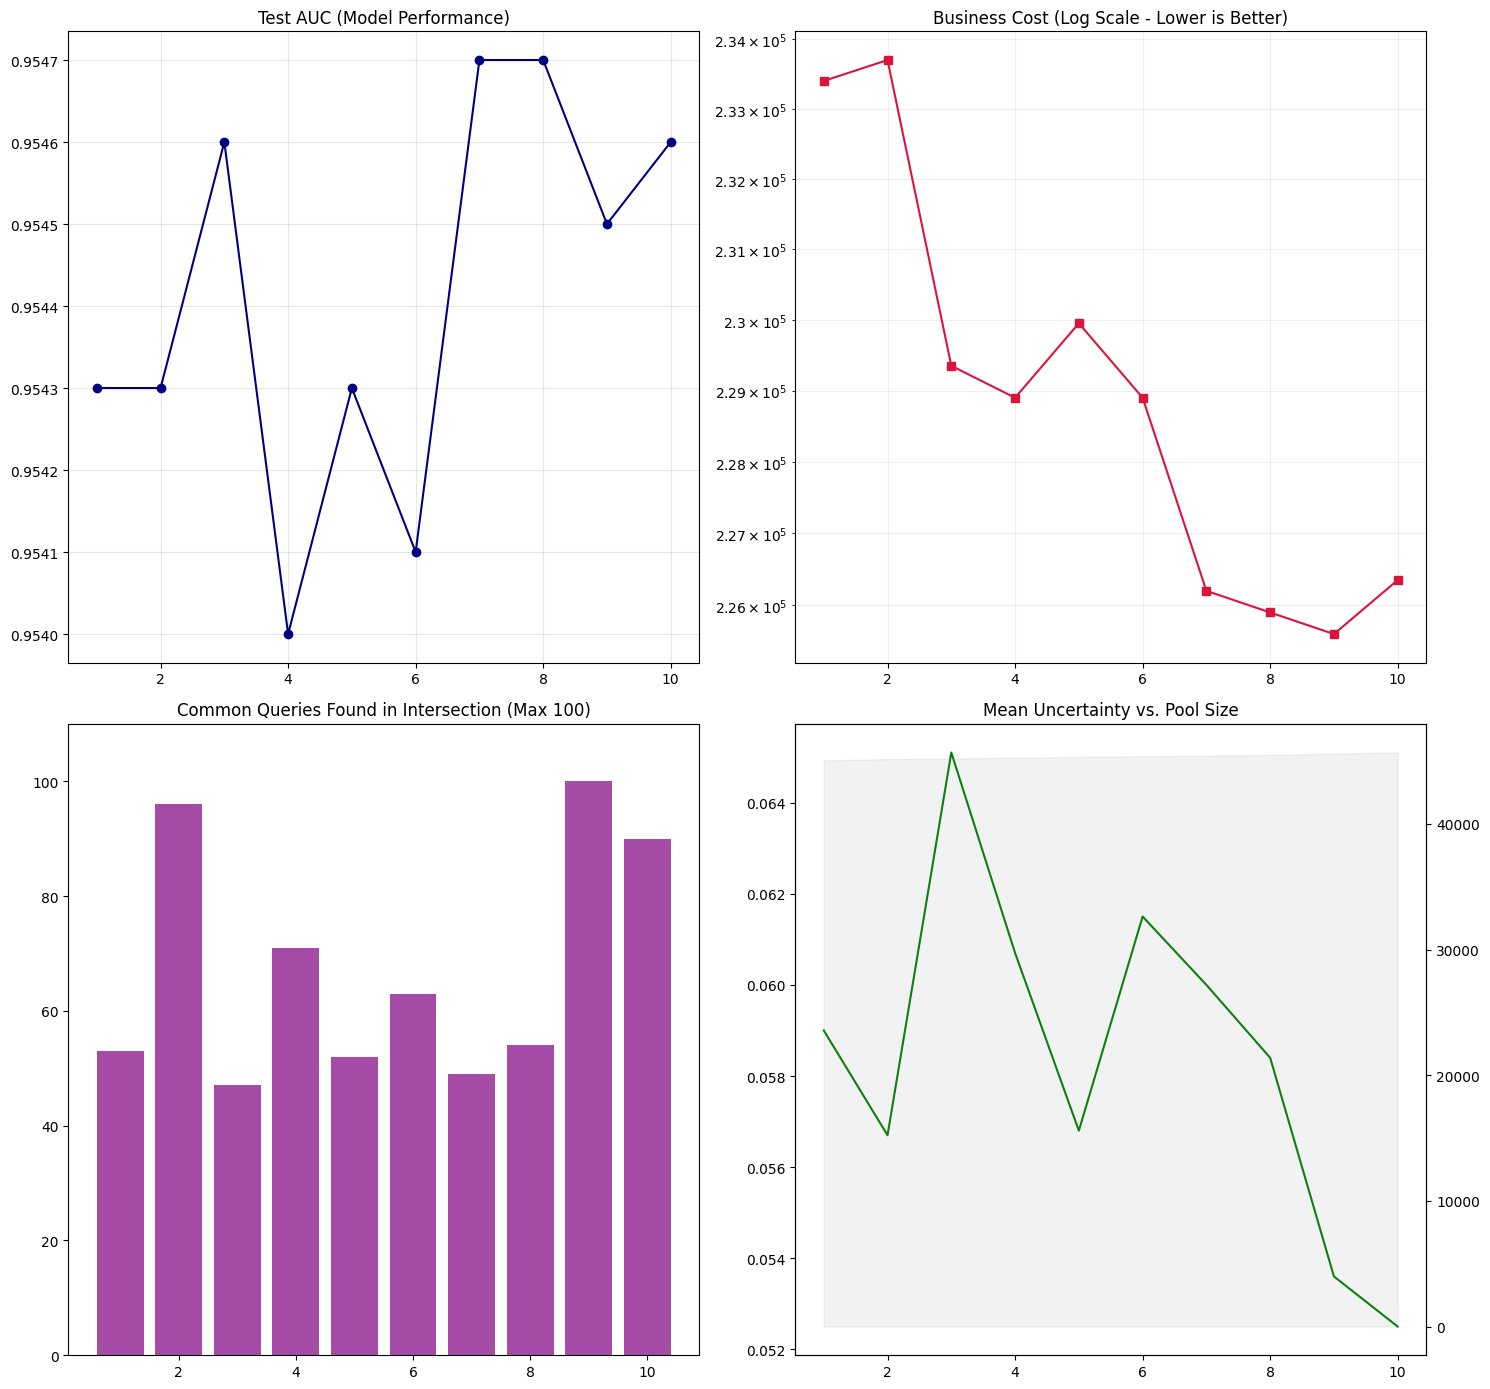

✅ Final Hybrid AL model saved → 'hybrid_al_final_model.json'

────────────────────────────────────────────────────────────────────────────────────────────────────
   Hybrid Active Learning Progression Summary
────────────────────────────────────────────────────────────────────────────────────────────────────
 loop  train_pool_size  unlabeled_remaining  common_queries  fraud_in_query  mean_uncertainty  test_auc  test_business_cost
    1            45053                18000              53               0            0.0590    0.9543            233400.0
    2            45149                16000              96               0            0.0567    0.9543            233700.0
    3            45196                14000              47               0            0.0651    0.9546            229350.0
    4            45267                12000              71               0            0.0607    0.9540            228900.0
    5            45319                10000              52           

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import clear_output
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings("ignore")

# ╔══════════════════════════════════════════════════════════╗
# ║                  HYBRID AL CONFIGURATION                 ║
# ╚══════════════════════════════════════════════════════════╝
N_CANDIDATES_PER_STRAT = 200   # Each strategy proposes this many queries
N_MAX_INTERSECT        = 100   # Max common queries to actually label
FINAL_HYBRID_AL_MODEL_PATH     = "hybrid_al_final_model.json"
# ── Working copies (mutated each loop) ───────────────────────
current_model   = baseline_model           # starts as baseline (xgb.Booster), updated each loop
X_train_current = c1_train_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])            # grows as new labels arrive
y_train_current = c1_train_data[TARGET_COL].values.astype(np.int32)
si_train_current = c1_train_data[SUM_INSURED_COL].values.astype(np.float64)



# --- INITIALIZE LIVE PLOT ---
plt.ion() # Turn on interactive mode

# ── AL Query Log CSV ─────────────────────────────────────────
HYBRID_AL_QUERY_LOG_CSV = "hybrid_al_queried_labels.csv"

# Wipe any previous run's file so we start fresh each full AL run
if os.path.exists(HYBRID_AL_QUERY_LOG_CSV):
    os.remove(HYBRID_AL_QUERY_LOG_CSV)
    print(f"🗑️  Cleared previous '{HYBRID_AL_QUERY_LOG_CSV}'")

print(f"📝 AL queries will be appended to '{HYBRID_AL_QUERY_LOG_CSV}' each loop.")

al_log = []

print(f"\n{'═'*65}")
print(f"  Starting Hybrid Active Learning — {N_AL_LOOPS} loops")
print(f"  Candidates per strat: {N_CANDIDATES_PER_STRAT} | Max Oracle Queries: {N_MAX_INTERSECT}")
print(f"{'═'*65}\n")
print(f'  Number of rows in df_remaining_unlabeled_pool = {len(df_remaining_unlabeled_pool)}')

for al_loop in tqdm(range(N_AL_LOOPS), desc="AL Loops", unit="loop"):
    # ── Slice this loop's non-overlapping subsample ───────────────────────
    chunk_start = al_loop * N_SUBSAMPLE
    chunk_end   = chunk_start + N_SUBSAMPLE
    df_chunk    = df_remaining_unlabeled_pool.drop(columns=[TARGET_COL]).iloc[chunk_start:chunk_end]

    # ── STEP 1: Score the subsample ───────────────────────────────────────
    X_unlabeled     = df_chunk.drop(columns=[SUM_INSURED_COL])
    proba_unlabeled = current_model.predict(
        xgb.DMatrix(X_unlabeled),
        iteration_range=(0, current_model.best_iteration + 1)
    )
    si_pool_vals = df_chunk[SUM_INSURED_COL].values.astype(np.float64)

    # ── STEP 2: Calculate scores for all 4 strategies ─────────────────────

    # Strategy 1: Pure Uncertainty
    score_unc = 0.5 - np.abs(proba_unlabeled - 0.5)
    idx_unc = set(np.argsort(-score_unc)[:N_CANDIDATES_PER_STRAT])

    # Strategy 2: Cost-weighted Uncertainty
    norm_cost = si_pool_vals / (si_pool_vals.max() + 1)
    score_cost_unc = score_unc * norm_cost
    idx_cost_unc = set(np.argsort(-score_cost_unc)[:N_CANDIDATES_PER_STRAT])

    # Strategy 3: Diversity (K-Means Distance-Weighted Uncertainty)
    # Standardizing features is crucial for K-Means to ensure all features contribute equally
    X_scaled = StandardScaler().fit_transform(X_unlabeled)
    n_clusters = min(N_CANDIDATES_PER_STRAT, len(X_scaled) // 2)
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init='auto').fit(X_scaled)
    # Calculate distances to nearest cluster center
    dists = np.min(kmeans.transform(X_scaled), axis=1)
    # Uncertainty: Scale 0 to 1, where 1 is most uncertain (proba = 0.5)
    uncertainty_score = 1 - np.abs(2 * proba_unlabeled - 1)
    # Combined Score: Uncertainty + normalized distance weight
    score_div = uncertainty_score + 0.5 * (dists / (dists.max() + 1e-6))
    idx_div = set(np.argsort(-score_div)[:N_CANDIDATES_PER_STRAT])

    # Strategy 4: Expected Cost Reduction
    # Calculates the financial risk the model is currently carrying for each row
    risk_if_0 = proba_unlabeled * (si_pool_vals * 0.9)  # Risk of False Negative (Missed Fraud)
    risk_if_1 = (1 - proba_unlabeled) * COST_FP         # Risk of False Positive (False Alarm)
    # Determine risk based on current model's decision at the optimal threshold
    current_risk = np.where(proba_unlabeled < THRESHOLD, risk_if_0, risk_if_1)
    # Query rows with the highest potential "regret" or current financial risk
    idx_ecr = set(np.argsort(-current_risk)[:N_CANDIDATES_PER_STRAT])




    # ── STEP 3: Intersection Logic ────────────────────────────────────────
    intersected_set = idx_unc & idx_cost_unc & idx_div & idx_ecr
    common_idx_all = list(intersected_set)

    num_common_found = len(common_idx_all)

    # Sort the common ones by cost-uncertainty and cap at N_MAX_INTERSECT
    if num_common_found > 0:
        common_idx_all_sorted = sorted(common_idx_all, key=lambda i: score_cost_unc[i], reverse=True)
        query_local_idx = common_idx_all_sorted[:N_MAX_INTERSECT]

        query_df          = df_chunk.iloc[query_local_idx].copy()
        query_proba       = proba_unlabeled[query_local_idx]
        query_uncertainty = score_unc[query_local_idx] # pure uncertainty for logging

        query_df["al_pred_proba"]  = query_proba
        query_df["al_uncertainty"] = query_uncertainty

        # Oracle lookup
        merge_cols = [c for c in unlabeled_oracle_join_cols if c in query_df.columns]
        newly_labeled = pd.merge(
            query_df,
            df_unlabeled_oracle[unlabeled_oracle_join_cols + [TARGET_COL]],
            on=merge_cols,
            how="left"
        )

        assert newly_labeled[TARGET_COL].notna().all(), \
            (f"Loop {al_loop+1}: {newly_labeled[TARGET_COL].isna().sum()} rows "
            f"failed oracle lookup — check that UNLABELED_CSV rows match the pool exactly.")
        # Save to CSV
        cols_to_save = df_labeled.columns.tolist() + ["al_pred_proba", "al_uncertainty"]
        save_df = newly_labeled[cols_to_save].copy()
        write_header = not os.path.exists(HYBRID_AL_QUERY_LOG_CSV)
        save_df.to_csv(HYBRID_AL_QUERY_LOG_CSV, mode="a", header=write_header, index=False)

        # Expand Training Pool
        FEATURE_COLS = [c for c in df_labeled.columns if c not in [TARGET_COL, SUM_INSURED_COL]]
        X_new  = newly_labeled[FEATURE_COLS].values
        y_new  = newly_labeled[TARGET_COL].values.astype(np.int32)
        si_new = newly_labeled[SUM_INSURED_COL].values.astype(np.float64)

        X_train_current  = pd.concat([X_train_current, pd.DataFrame(X_new, columns=FEATURE_COLS)], ignore_index=True)
        y_train_current  = np.concatenate([y_train_current, y_new])
        si_train_current = np.concatenate([si_train_current, si_new])

        # Retrain model with new data
        current_model = build_and_train_model(
            xgb_params, N_ESTIMATORS, THRESHOLD, X_train_current, y_train_current, si_train_current
        )

        loop_fraud_found = int(y_new.sum())
        loop_mean_unc    = round(float(query_uncertainty.mean()), 4)
    else:
        # Fallback if intersection is entirely empty (no queries made this loop)
        loop_fraud_found = 0
        loop_mean_unc    = 0.0

    # ── STEP 4: Compute test-set stats for progress tracking ──────────────
    test_proba = current_model.predict(
        xgb.DMatrix(c2_test_data.drop(columns=[TARGET_COL, SUM_INSURED_COL])),
        iteration_range=(0, current_model.best_iteration + 1)
    )
    test_cost = compute_business_cost(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba,
                                        c2_test_data[SUM_INSURED_COL].values.astype(np.float64), THRESHOLD)
    test_auc  = roc_auc_score(c2_test_data[TARGET_COL].values.astype(np.int32), test_proba)

    loop_stats = {
        "loop"                : al_loop + 1,
        "train_pool_size"     : len(y_train_current),
        "unlabeled_remaining" : len(df_remaining_unlabeled_pool) - chunk_end,
        "common_queries"      : min(num_common_found, N_MAX_INTERSECT), # Track intersection size
        "fraud_in_query"      : loop_fraud_found,
        "mean_uncertainty"    : loop_mean_unc,
        "test_auc"            : round(test_auc, 4),
        "test_business_cost"  : round(test_cost, 2),
    }
    al_log.append(loop_stats)

    # ── STEP 5: LIVE PLOT UPDATE ────────────────────────────────────────
    df_temp = pd.DataFrame(al_log)
    clear_output(wait=True)

    # Changed to 3x2 Grid to fit the new Common Queries plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 14))

    # Plot 1: AUC Progression
    axes[0, 0].plot(df_temp['loop'], df_temp['test_auc'], marker='o', color='navy')
    axes[0, 0].set_title('Test AUC (Model Performance)')
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Business Cost
    axes[0, 1].plot(df_temp['loop'], df_temp['test_business_cost'], marker='s', color='crimson')
    axes[0, 1].set_yscale('log')
    axes[0, 1].set_title('Business Cost (Log Scale - Lower is Better)')
    axes[0, 1].grid(True, which="both", ls="-", alpha=0.2)

    # Plot 3: Fraud Detection Rate in Query
    # axes[1, 0].bar(df_temp['loop'], df_temp['fraud_in_query'], color='orange', alpha=0.7)
    # axes[1, 0].set_title('Frauds Found in Current Query Batch')

    # Plot 4: Uncertainty & Pool Size
    ax2 = axes[1, 1].twinx()
    axes[1, 1].plot(df_temp['loop'], df_temp['mean_uncertainty'], color='green', label='Uncertainty')
    ax2.fill_between(df_temp['loop'], df_temp['train_pool_size'], color='gray', alpha=0.1, label='Pool Size')
    axes[1, 1].set_title('Mean Uncertainty vs. Pool Size')

    # Plot 5: Number of Common Queries (The Hybrid Output)
    axes[1, 0].bar(df_temp['loop'], df_temp['common_queries'], color='purple', alpha=0.7)
    axes[1, 0].set_title(f'Common Queries Found in Intersection (Max {N_MAX_INTERSECT})')
    axes[1, 0].set_ylim(0, N_MAX_INTERSECT + 10)

    # Hide the empty 6th subplot pane
    # axes[2, 1].axis('off')

    plt.tight_layout()
    plt.show()

# ── Save final retrained XGBoost booster ─────────────────────
current_model.save_model(FINAL_HYBRID_AL_MODEL_PATH)
print(f"✅ Final Hybrid AL model saved → '{FINAL_HYBRID_AL_MODEL_PATH}'")

# ── AL progression table ─────────────────────────────────────
df_log = pd.DataFrame(al_log)
print(f"\n{'─'*100}")
print(f"   Hybrid Active Learning Progression Summary")
print(f"{'─'*100}")
print(df_log.to_string(index=False))
print(f"{'─'*100}")

# ── COMPREHENSIVE COMPARISON ─────────────────────────────────
hybrid_al_auc  = df_log["test_auc"].iloc[-1]
hybrid_al_cost = df_log["test_business_cost"].iloc[-1]
final_pool = df_log["train_pool_size"].iloc[-1]
total_frauds_found = df_log["fraud_in_query"].sum()
total_queries_made = df_log["common_queries"].sum()

print(f"\n{'═'*65}")
print(f"   BASELINE vs. FINAL HYBRID ACTIVE LEARNING MODEL")
print(f"{'═'*65}")

comparison_data = {
    "Metric": ["AUC", "Business Cost", "Total Queries Made", "Fraud Found in AL"],
    "Baseline": [f"{baseline_auc:.4f}", f"${baseline_cost:,.2f}", "-", "-"],
    "HYBRID AL": [f"{hybrid_al_auc:.4f}", f"${hybrid_al_cost:,.2f}", f"{total_queries_made}", f"{total_frauds_found}"],
    "Delta": [f"{hybrid_al_auc - baseline_auc:+.4f}",
              f"${hybrid_al_cost - baseline_cost:+,.2f}",
              "N/A", "N/A"]
}

print(pd.DataFrame(comparison_data).to_string(index=False))
print(f"{'═'*65}")

improvement_pct = ((baseline_cost - hybrid_al_cost) / baseline_cost) * 100
print(f"💡 Summary: Hybrid AL reduced business cost by {improvement_pct:.2f}%")
print(f"   The model queried {total_queries_made} highly robust rows, yielding {total_frauds_found} high-value fraud cases.")

The Hybrid AL is being "too picky." By using a strict Intersection (&), we have created a high-bar consensus filter that prioritizes Model Stability over Fraud Discovery.

SIMPLE AL (Uncertainty * Cost) - If a row is a high-value fraud and the model is even slightly unsure, it gets queried.

HYBRID AL - Must satisfy 4 different mathematical conditions simultaneously:

*   Uncertainty: It must be near the 0.5 probability boundary.
*   Cost: It must have a high sum_insured.
*   Diversity: It must be in a "lonely" part of the feature space (far from other points).
*   Expected Cost Reduction (ECR): It must represent a high financial risk based on the current threshold.

The Result: Fraud cases often "cluster". The Diversity strategy specifically hates clusters. If 10 potential fraud cases are near each other, Diversity will likely only pick one or reject them if they are too close to existing training data. By requiring all four strategies to agree, we are filtering out "obvious" fraud candidates in favor of "mathematically weird" cases.


Essentially, we are looking for a **"diverse, high-cost, high-risk, uncertain"** point.

## Baseline vs AL vs NSL vs Hybrid AL

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — Baseline vs Non-Sequential vs AL vs Hybrid AL
# ══════════════════════════════════════════════════════════════════

# ── Step 0: Save the baseline model (add this right after baseline_model is trained above) ──
# If you still have `baseline_model` in memory, just save it now:
BASELINE_MODEL_PATH = "baseline_model.json"
baseline_model.save_model(BASELINE_MODEL_PATH)
print(f"✅ Baseline model saved → '{BASELINE_MODEL_PATH}'")


# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

df_sampled               = df_remaining_unlabeled.sample(n=1000, random_state=60)
df_unlabeled_al_samples  = pd.read_csv('/content/al_queried_labels.csv')
# NEW: Load Hybrid AL queried data to ensure it is excluded from the test set
df_hybrid_al_samples     = pd.read_csv('/content/hybrid_al_queried_labels.csv')
df_unlabeled             = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen (training pool, AL queries, Hybrid AL queries, random sample)
seen = pd.concat([
    df_sampled[df_unlabeled.columns],
    df_unlabeled_al_samples[df_unlabeled.columns],
    df_hybrid_al_samples[df_unlabeled.columns], # NEW: Added to seen
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

# Note: df_unlabeled may have duplicate rows internally, so
# len(seen) + len(df_final_test) can differ from len(df_unlabeled)
print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    print(f"\n{'═'*62}")
    print(f"  {label}")
    print(f"{'═'*62}")
    print(f"  Threshold         : {threshold:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  Business cost     : {biz_cost:>15,.2f}")
    print(f"  Cost per row      : {cost_per_row:>15,.4f}")
    print(f"  TP / FP / TN / FN : {tp} / {fp} / {tn} / {fn}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print(f"  F1                : {f1:.4f}")
    print(f"{'═'*62}")

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load all four models ─────────────────────────────────────────────
booster_baseline  = xgb.Booster(); booster_baseline.load_model(BASELINE_MODEL_PATH)
booster_ns        = xgb.Booster(); booster_ns.load_model(FINAL_NON_SEQUENTIAL_MODEL_PATH)
booster_al        = xgb.Booster(); booster_al.load_model(FINAL_MODEL_PATH)
booster_hybrid_al = xgb.Booster(); booster_hybrid_al.load_model(FINAL_HYBRID_AL_MODEL_PATH) # NEW


# ── Step 5: Evaluate all four ────────────────────────────────────────────────
stats_baseline = evaluate_model(
    booster_baseline, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Baseline (labeled pool only)"
)
stats_ns = evaluate_model(
    booster_ns, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Non-Sequential (random 1k unlabeled)"
)
stats_al = evaluate_model(
    booster_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Active Learning (Cost-weighted Uncertainty)"
)
stats_hybrid_al = evaluate_model(
    booster_hybrid_al, dtest_final, y_test_final, si_test_final,
    THRESHOLD, label="Hybrid AL (Multi-Strategy)"
) # NEW


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_baseline, stats_ns, stats_al, stats_hybrid_al]) # NEW: Added hybrid stats
    .set_index("model")
    .T
)

print(f"\n{'─'*100}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*100}")
print(df_compare.to_string())
print(f"{'─'*100}")


# ── Step 7: Deltas vs Baseline ───────────────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")

delta_row(stats_ns, stats_baseline, "Non-Sequential", "Baseline")
delta_row(stats_al, stats_baseline, "AL",             "Baseline")

# NEW: Added Hybrid comparisons
delta_row(stats_hybrid_al, stats_baseline, "Hybrid AL", "Baseline")
print("\n" + "═"*60)
print("HYBRID AL vs AL (Cost-Weighted Uncertainty)")
print("═"*60)
delta_row(stats_hybrid_al, stats_al, "Hybrid AL", "AL")

✅ Baseline model saved → 'baseline_model.json'
df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 2,313
final held-out test rows     : 27,707
(gap = internal dupes in df_unlabeled: -20)

[FINAL TEST SET] 27,707 rows | fraud=843 (3.04%)

══════════════════════════════════════════════════════════════
  Baseline (labeled pool only)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9553
  Business cost     :      617,400.00
  Cost per row      :         22.2832
  TP / FP / TN / FN : 843 / 3554 / 23310 / 0
  Precision         : 0.1917
  Recall            : 1.0000
  F1                : 0.3218
══════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════
  Non-Sequential (random 1k unlabeled)
══════════════════════════════════════════════════════════════
  Threshold         : 0.1085
  AUC-ROC           : 0.9561
  Business cost     :      616,800.

## AL (various strategies) vs Hybrid AL

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL EVALUATION — 4 Individual AL Strategies vs Hybrid AL
# ══════════════════════════════════════════════════════════════════

# ── Step 1: Build final held-out test set (never seen in training or AL) ─────

# Load all queried logs to ensure they are excluded from the final test set
df_al_simple = pd.read_csv('/content/al_queried_labels_simple_uncertainty.csv')
df_al_cost   = pd.read_csv('/content/al_queried_labels_cost_weighted_uncertainty.csv')
df_al_div    = pd.read_csv('/content/al_queried_labels_diversity_k_means_with_distance_uncertainty.csv')
df_al_ecr    = pd.read_csv('/content/al_queried_labels_expected_cost_reduction.csv')
df_hybrid    = pd.read_csv('/content/hybrid_al_queried_labels.csv')

df_unlabeled = pd.read_csv('/content/unlabeled_synthetic_insurance_claims_with_fraud_3%_label.csv')

# Union of ALL rows ever seen by ANY of the models
seen = pd.concat([
    df_al_simple[df_unlabeled.columns],
    df_al_cost[df_unlabeled.columns],
    df_al_div[df_unlabeled.columns],
    df_al_ecr[df_unlabeled.columns],
    df_hybrid[df_unlabeled.columns],
], ignore_index=True).drop_duplicates()

# Anti-join: keep only rows in df_unlabeled that were never seen
merge_cols = df_unlabeled.columns.tolist()

df_final_test = (
    df_unlabeled
    .merge(seen, on=merge_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
    .drop(columns="_merge")
    .reset_index(drop=True)
)

print(f"df_unlabeled total rows      : {len(df_unlabeled):,}")
print(f"seen rows (union, deduped)   : {len(seen):,}")
print(f"final held-out test rows     : {len(df_final_test):,}")
print(f"(gap = internal dupes in df_unlabeled: "
      f"{len(df_unlabeled) - len(seen) - len(df_final_test):,})")

# ── Step 2: Build DMatrix for final test ──────────────────────────────────────
X_test_final  = df_final_test.drop(columns=[TARGET_COL, SUM_INSURED_COL])
y_test_final  = df_final_test[TARGET_COL].values.astype(np.int32)
si_test_final = df_final_test[SUM_INSURED_COL].values.astype(np.float64)
dtest_final   = xgb.DMatrix(X_test_final)

print(f"\n[FINAL TEST SET] {len(df_final_test):,} rows | "
      f"fraud={y_test_final.sum():,} ({100*y_test_final.mean():.2f}%)")


# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
def evaluate_model(booster, dmat, y_true, si_vals, threshold, label):
    y_proba = booster.predict(dmat, iteration_range=(0, booster.best_iteration + 1))
    y_pred  = (y_proba >= threshold).astype(int)

    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))

    precision    = tp / max(tp + fp, 1)
    recall       = tp / max(tp + fn, 1)
    f1           = 2 * precision * recall / max(precision + recall, 1e-9)
    auc          = roc_auc_score(y_true, y_proba)
    biz_cost     = compute_business_cost(y_true, y_proba, si_vals, threshold)
    cost_per_row = biz_cost / max(len(y_true), 1)

    return {
        "model"        : label,
        "auc"          : round(auc, 4),
        "biz_cost"     : round(biz_cost, 2),
        "cost_per_row" : round(cost_per_row, 4),
        "tp"           : tp, "fp": fp, "tn": tn, "fn": fn,
        "precision"    : round(precision, 4),
        "recall"       : round(recall, 4),
        "f1"           : round(f1, 4),
    }


# ── Step 4: Load all five models ─────────────────────────────────────────────
booster_simple = xgb.Booster(); booster_simple.load_model('al_final_model_simple_uncertainty.json')
booster_cost   = xgb.Booster(); booster_cost.load_model('al_final_model_cost_weighted_uncertainty.json')
booster_div    = xgb.Booster(); booster_div.load_model('al_final_model_diversity_k_means_with_distance_uncertainty.json')
booster_ecr    = xgb.Booster(); booster_ecr.load_model('al_final_model_expected_cost_reduction.json')
booster_hybrid = xgb.Booster(); booster_hybrid.load_model('hybrid_al_final_model.json')


# ── Step 5: Evaluate all five ────────────────────────────────────────────────
stats_simple = evaluate_model(booster_simple, dtest_final, y_test_final, si_test_final, THRESHOLD, "AL (Simple)")
stats_cost   = evaluate_model(booster_cost,   dtest_final, y_test_final, si_test_final, THRESHOLD, "AL (Cost-Weighted)")
stats_div    = evaluate_model(booster_div,    dtest_final, y_test_final, si_test_final, THRESHOLD, "AL (Diversity)")
stats_ecr    = evaluate_model(booster_ecr,    dtest_final, y_test_final, si_test_final, THRESHOLD, "AL (Expected Cost)")
stats_hybrid = evaluate_model(booster_hybrid, dtest_final, y_test_final, si_test_final, THRESHOLD, "Hybrid AL")


# ── Step 6: Side-by-side comparison table ────────────────────────────────────
df_compare = (
    pd.DataFrame([stats_simple, stats_cost, stats_div, stats_ecr, stats_hybrid])
    .set_index("model")
    .T
)

print(f"\n{'─'*110}")
print(f"  Head-to-head comparison on final held-out test set ({len(y_test_final):,} rows)")
print(f"{'─'*110}")
print(df_compare.to_string())
print(f"{'─'*110}")


# ── Step 7: Deltas vs Hybrid AL ──────────────────────────────────────────────
def delta_row(stats_a, stats_b, label_a, label_b):
    print(f"\n  Δ  {label_a}  vs  {label_b}  (positive = {label_a} better for AUC/recall/f1)")
    d_auc  = stats_a["auc"]      - stats_b["auc"]
    d_cost = stats_a["biz_cost"] - stats_b["biz_cost"]
    d_rec  = stats_a["recall"]   - stats_b["recall"]
    d_f1   = stats_a["f1"]       - stats_b["f1"]
    print(f"  AUC          : {d_auc:+.4f}")
    print(f"  Business cost: {d_cost:+,.2f}   "
          f"{'✅ cheaper' if d_cost < 0 else '❌ more expensive'}")
    print(f"  Recall       : {d_rec:+.4f}")
    print(f"  F1           : {d_f1:+.4f}")


print("\n" + "═"*60)
print("HYBRID AL vs INDIVIDUAL STRATEGIES")
print("═"*60)

delta_row(stats_hybrid, stats_simple, "Hybrid AL", "AL (Simple)")
delta_row(stats_hybrid, stats_cost,   "Hybrid AL", "AL (Cost-Weighted)")
delta_row(stats_hybrid, stats_div,    "Hybrid AL", "AL (Diversity)")
delta_row(stats_hybrid, stats_ecr,    "Hybrid AL", "AL (Expected Cost)")

df_unlabeled total rows      : 30,000
seen rows (union, deduped)   : 2,417
final held-out test rows     : 27,583
(gap = internal dupes in df_unlabeled: 0)

[FINAL TEST SET] 27,583 rows | fraud=840 (3.05%)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Head-to-head comparison on final held-out test set (27,583 rows)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
model         AL (Simple)  AL (Cost-Weighted)  AL (Diversity)  AL (Expected Cost)    Hybrid AL
auc                0.9563              0.9558          0.9572              0.9567       0.9570
biz_cost      589200.0000         589350.0000     587100.0000         588600.0000  587250.0000
cost_per_row      21.3610             21.3664         21.2848             21.3392      21.2903
tp               840.0000            840.0000        840.0000            840.0000     840.0000
fp              3368.0000     